# Task 2 — Proposed CNN + GCN + Multi-Head Attention Model

The first proposed CNN + GCN + Multi-Head Self-Attention model, including preprocessing, training, cross-validation, evaluation utilities, class-imbalance handling, and the required architecture diagram.



In [1]:
# ----------------------------------------------------------------
# 1. CONFIG
# ----------------------------------------------------------------
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

# On Kaggle, this dataset will typically be mounted at:
DATASET_DIR = "/kaggle/input/datasets/redoanmozumder/eurosatsatalite"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Sentinel-2 band order for EuroSAT MS tiles (0-indexed array positions)
BAND_NAMES = ["B01", "B02", "B03", "B04", "B05", "B06", "B07",
              "B08", "B08A", "B09", "B10", "B11", "B12"]
BAND_BLUE, BAND_GREEN, BAND_RED, BAND_NIR = 1, 2, 3, 7   # 0-indexed positions in BAND_NAMES

STATS_SAMPLE_N = 300
CORRUPT_CHECK_ALL = True

In [2]:
# ----------------------------------------------------------------
# 2. LOCATE CLASS FOLDERS AND BUILD A DATAFRAME OF IMAGE PATHS + LABELS
# ----------------------------------------------------------------
def find_class_root(base_dir):
    """Walk down until we find a directory whose subfolders look like class folders,
    specifically requiring .tif/.tiff content (MS data)."""
    base_dir = Path(base_dir)
    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for cand in candidates:
        subdirs = [d for d in cand.iterdir() if d.is_dir()]
        if len(subdirs) >= 2:
            has_tif = sum(
                1 for d in subdirs
                if any(f.suffix.lower() in (".tif", ".tiff") for f in d.iterdir() if f.is_file())
            )
            if has_tif >= max(2, len(subdirs) // 2):
                return cand
    return base_dir


def get_image_paths_and_labels(class_root):
    image_exts = {".tif", ".tiff"}
    records = []
    class_root = Path(class_root)
    classes = sorted([d.name for d in class_root.iterdir() if d.is_dir()])
    for cls in classes:
        cls_dir = class_root / cls
        for f in cls_dir.iterdir():
            if f.is_file() and f.suffix.lower() in image_exts:
                records.append({"filepath": str(f), "label": cls})
    return pd.DataFrame(records), classes


class_root = find_class_root(DATASET_DIR)
print(f"Detected class-folder root: {class_root}")

df, class_names = get_image_paths_and_labels(class_root)
print(f"Total images found: {len(df)}")
print(f"Classes ({len(class_names)}): {class_names}")

df.to_csv("eurosat_ms_index.csv", index=False)  # handy cache of paths+labels

Detected class-folder root: /kaggle/input/datasets/redoanmozumder/eurosatsatalite/ds/images/remote_sensing/otherDatasets/sentinel_2/tif
Total images found: 27000
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']



Per-band statistics (sampled):
     band  min      max         mean          std
0    B01  0.0   3993.0  1359.130106   246.479671
1    B02  0.0  21277.0  1122.516440   345.059208
2    B03  0.0  24028.0  1045.034892   414.723489
3    B04  0.0  22898.0   947.351520   608.250334
4    B05  0.0  12529.0  1190.086256   576.738574
5    B06  0.0  15141.0  1978.352380   878.649208
6    B07  0.0  14740.0  2342.695548  1102.359410
7    B08  0.0  26479.0  2264.641785  1130.226861
8   B08A  0.0   2608.0   696.072755   397.937545
9    B09  0.0     49.0    11.865475     4.376295
10   B10  0.0  15153.0  1800.789372  1020.811619
11   B11  0.0  14764.0  1106.054294   774.675250
12   B12  0.0  15513.0  2562.211921  1250.300089


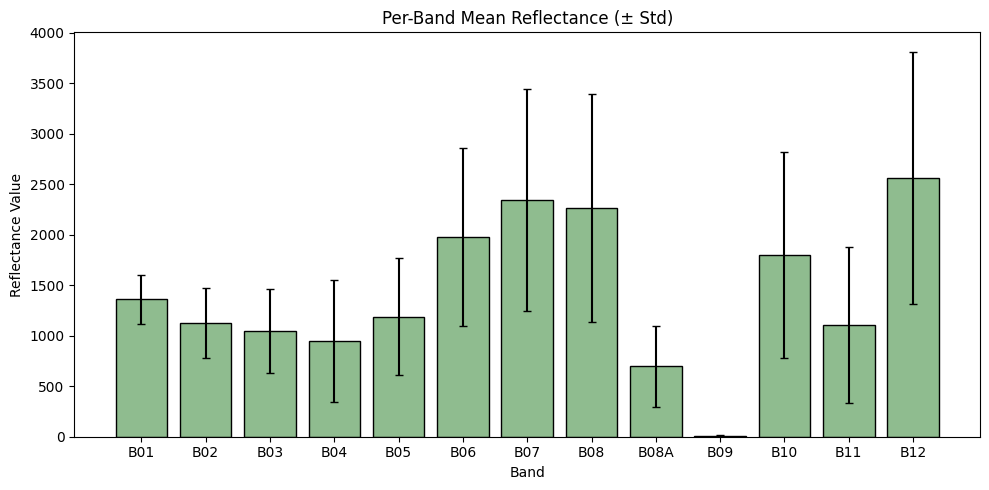

In [7]:
# ----------------------------------------------------------------
# 7. PER-BAND STATISTICS (MIN / MAX / MEAN / STD ACROSS ALL 13 BANDS)
# ----------------------------------------------------------------
def get_band_array(path):
    img = tifffile.imread(path).astype(np.float32)
    if img.shape[0] == len(BAND_NAMES):
        img = np.moveaxis(img, 0, -1)
    return img  # (H, W, 13)


sample_paths = df["filepath"].sample(min(STATS_SAMPLE_N, len(df)), random_state=SEED).values

band_mins = np.zeros(len(BAND_NAMES))
band_maxs = np.zeros(len(BAND_NAMES))
band_sums = np.zeros(len(BAND_NAMES))
band_sq_sums = np.zeros(len(BAND_NAMES))
pixel_count = 0

for p in sample_paths:
    arr = get_band_array(p)
    h, w, c = arr.shape
    pixel_count += h * w
    for b in range(c):
        band_mins[b] = min(band_mins[b], arr[:, :, b].min())
        band_maxs[b] = max(band_maxs[b], arr[:, :, b].max())
        band_sums[b] += arr[:, :, b].sum()
        band_sq_sums[b] += (arr[:, :, b] ** 2).sum()

band_means = band_sums / pixel_count
band_stds = np.sqrt(band_sq_sums / pixel_count - band_means ** 2)

band_stats = pd.DataFrame({
    "band": BAND_NAMES,
    "min": band_mins,
    "max": band_maxs,
    "mean": band_means,
    "std": band_stds,
})
print("\nPer-band statistics (sampled):\n", band_stats)

plt.figure(figsize=(10, 5))
plt.bar(band_stats["band"], band_stats["mean"], yerr=band_stats["std"],
        color="darkseagreen", edgecolor="black", capsize=3)
plt.title("Per-Band Mean Reflectance (± Std)")
plt.xlabel("Band")
plt.ylabel("Reflectance Value")
plt.tight_layout()
plt.savefig("band_stats.png", dpi=150)
plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)
 
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
 
NUM_CLASSES = len(class_names)
BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5          # early stopping patience (epochs without val-loss improvement)
LR = 1e-3
WEIGHT_DECAY = 1e-4
 
label_to_idx = {cls: i for i, cls in enumerate(sorted(class_names))}
idx_to_label = {i: cls for cls, i in label_to_idx.items()}
 

Using device: cuda


In [20]:
# ----------------------------------------------------------------
# 3. DATA SPLIT — HELD-OUT TEST + STRATIFIED K-FOLD DEVELOPMENT SET
# ----------------------------------------------------------------
# 80% = development set for 5-fold CV
# 20% = final untouched test set

from sklearn.model_selection import train_test_split, StratifiedKFold

dev_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

dev_df = dev_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

N_FOLDS = 5
CV_EPOCHS = 8          # short CV runs for model/hyperparameter selection
FINAL_EPOCHS = 25      # full training after CV
FINETUNE_EPOCHS = 8    # low-LR fine-tuning stage
CV_BATCH_SIZE = BATCH_SIZE

print(f"Development set: {len(dev_df)}")
print(f"Final untouched test set: {len(test_df)}")
print(f"K-folds: {N_FOLDS}")
print("K-fold CV is performed ONLY on the development set.")


Development set: 21600
Final untouched test set: 5400
K-folds: 5
K-fold CV is performed ONLY on the development set.


In [21]:
NORM_SAMPLE_N = 500
norm_sample = dev_df.sample(min(NORM_SAMPLE_N, len(dev_df)), random_state=SEED)
 
band_sums = np.zeros(len(BAND_NAMES))
band_sq_sums = np.zeros(len(BAND_NAMES))
pixel_count = 0
 
for p in norm_sample["filepath"]:
    arr = get_band_array(p).astype(np.float32)
    h, w, c = arr.shape
    pixel_count += h * w
    band_sums += arr.sum(axis=(0, 1))
    band_sq_sums += (arr ** 2).sum(axis=(0, 1))
 
BAND_MEAN = band_sums / pixel_count
BAND_STD = np.sqrt(band_sq_sums / pixel_count - BAND_MEAN ** 2) + 1e-8
 
print("Band means:", BAND_MEAN)
print("Band stds:", BAND_STD)
 


Band means: [1341.91158496 1108.60032227 1033.80812354  944.28988916 1186.25269678
 1958.10784961 2325.26246729 2249.59690869  694.50192725   11.92305469
 1797.15374072 1106.58754248 2543.90435693]
Band stds: [ 219.29428721  315.44382767  385.84985807  589.57722991  572.42718846
  893.21593242 1130.75155442 1155.09699622  392.87779719    5.98084042
 1030.27934003  768.15891491 1280.24836697]


In [22]:
# ----------------------------------------------------------------
# 4. DATASET + AUGMENTATION
# ----------------------------------------------------------------

from torch.utils.data import Dataset, DataLoader

    
class EuroSATMSDataset(Dataset):
    def __init__(self, dataframe, mean, std, train=False, aug_level="standard"):
        self.df = dataframe.reset_index(drop=True)
        self.mean = mean.reshape(-1, 1, 1).astype(np.float32)
        self.std = std.reshape(-1, 1, 1).astype(np.float32)
        self.train = train
        self.aug_level = aug_level

    def __len__(self):
        return len(self.df)

    def _standard_spatial_aug(self, arr):
        if np.random.rand() < 0.5:
            arr = arr[:, :, ::-1].copy()
        if np.random.rand() < 0.5:
            arr = arr[:, ::-1, :].copy()
        k = np.random.randint(0, 4)
        arr = np.rot90(arr, k, axes=(1, 2)).copy()
        return arr

    def _strong_gcn_aug(self, arr):
        arr = self._standard_spatial_aug(arr)

        if np.random.rand() < 0.25:
            arr = arr.transpose(0, 2, 1).copy()

        if np.random.rand() < 0.30:
            shift_y = np.random.randint(-3, 4)
            shift_x = np.random.randint(-3, 4)
            h, w = arr.shape[1], arr.shape[2]
            pad = 4
            padded = np.pad(arr, ((0,0),(pad,pad),(pad,pad)), mode="reflect")
            arr = padded[
                :, pad + shift_y:pad + shift_y + h,
                   pad + shift_x:pad + shift_x + w
            ].copy()

        if np.random.rand() < 0.45:
            arr = arr * np.random.uniform(0.90, 1.10)

        if np.random.rand() < 0.35:
            band_gain = np.random.uniform(
                0.95, 1.05, size=(arr.shape[0],1,1)
            ).astype(np.float32)
            arr = arr * band_gain

        if np.random.rand() < 0.35:
            noise_scale = np.random.uniform(0.005, 0.02)
            arr = arr + np.random.normal(
                0.0, noise_scale, size=arr.shape
            ).astype(np.float32)

        if np.random.rand() < 0.20:
            n_drop = 1 if np.random.rand() < 0.85 else 2
            for b in np.random.choice(arr.shape[0], size=n_drop, replace=False):
                arr[b] = arr[b].mean()

        return np.clip(arr, 0.0, None).astype(np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = get_band_array(row["filepath"]).astype(np.float32)
        arr = np.moveaxis(arr, -1, 0)

        if self.train:
            if self.aug_level == "strong":
                arr = self._strong_gcn_aug(arr)
            else:
                arr = self._standard_spatial_aug(arr)

        arr = (arr - self.mean) / self.std
        label = label_to_idx[row["label"]]
        return torch.tensor(arr, dtype=torch.float32), label


def make_loaders(train_part, val_part, mean, std, strong_train=False, batch_size=BATCH_SIZE):
    train_ds_local = EuroSATMSDataset(
        train_part, mean, std, train=True,
        aug_level="strong" if strong_train else "standard"
    )
    val_ds_local = EuroSATMSDataset(
        val_part, mean, std, train=False, aug_level="none"
    )
    return (
        DataLoader(train_ds_local, batch_size=batch_size, shuffle=True,
                   num_workers=2, pin_memory=torch.cuda.is_available()),
        DataLoader(val_ds_local, batch_size=batch_size, shuffle=False,
                   num_workers=2, pin_memory=torch.cuda.is_available())
    )


# Full development-set loaders used after CV for final fine-tuning.
full_dev_resnet_ds = EuroSATMSDataset(dev_df, BAND_MEAN, BAND_STD, train=True, aug_level="standard")
full_dev_gcn_ds = EuroSATMSDataset(dev_df, BAND_MEAN, BAND_STD, train=True, aug_level="strong")
test_ds = EuroSATMSDataset(test_df, BAND_MEAN, BAND_STD, train=False, aug_level="none")

full_dev_resnet_loader = DataLoader(
    full_dev_resnet_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
full_dev_gcn_loader = DataLoader(
    full_dev_gcn_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

print("5-fold CV: train folds augmented; validation fold untouched.")
print("Final test: untouched.")


5-fold CV: train folds augmented; validation fold untouched.
Final test: untouched.


In [32]:
# ----------------------------------------------------------------
# 12. MODEL 3 — CNN + GCN + MULTI-HEAD ATTENTION
# ----------------------------------------------------------------

class GraphConv(nn.Module):
    """Simple dense GCN layer: H' = A_norm H W."""
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, x, adj_norm):
        # x: [B, N, F], adj_norm: [N, N]
        x = torch.matmul(adj_norm, x)
        return self.linear(x)


def make_grid_adjacency(size=8, self_loop=True):
    """Build an 8-neighbor spatial graph for an size x size feature map."""
    n = size * size
    a = torch.zeros(n, n, dtype=torch.float32)
    for r in range(size):
        for c in range(size):
            i = r * size + c
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    if dr == 0 and dc == 0:
                        continue
                    rr, cc = r + dr, c + dc
                    if 0 <= rr < size and 0 <= cc < size:
                        j = rr * size + cc
                        a[i, j] = 1.0
    if self_loop:
        a += torch.eye(n)
    degree = a.sum(dim=1)
    d_inv_sqrt = torch.pow(degree.clamp_min(1e-8), -0.5)
    d_mat = torch.diag(d_inv_sqrt)
    return d_mat @ a @ d_mat


class CNN_GCN_Attention(nn.Module):
    def __init__(self, in_channels=13, num_classes=10, gcn_dim=128,
                 num_heads=4, dropout=0.35):
        super().__init__()

        # CNN: 64x64 -> 32x32 -> 16x16 -> 8x8
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.gcn1 = GraphConv(128, gcn_dim)
        self.gcn2 = GraphConv(gcn_dim, gcn_dim)
        self.norm1 = nn.LayerNorm(gcn_dim)
        self.norm2 = nn.LayerNorm(gcn_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=gcn_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.attn_norm = nn.LayerNorm(gcn_dim)
        self.ffn = nn.Sequential(
            nn.Linear(gcn_dim, gcn_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(gcn_dim * 2, gcn_dim),
        )
        self.ffn_norm = nn.LayerNorm(gcn_dim)

        # Learnable attention pooling over graph nodes
        self.pool_score = nn.Sequential(
            nn.Linear(gcn_dim, gcn_dim // 2),
            nn.Tanh(),
            nn.Linear(gcn_dim // 2, 1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gcn_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

        # 8x8 = 64 graph nodes. Registered as a buffer so it moves with the model.
        self.register_buffer("adj_norm", make_grid_adjacency(8), persistent=False)

    def forward(self, x):
        feat = self.cnn(x)                         # [B, 128, 8, 8]
        nodes = feat.flatten(2).transpose(1, 2)   # [B, 64, 128]

        h = F.relu(self.gcn1(nodes, self.adj_norm))
        h = self.norm1(h)
        h = F.relu(self.gcn2(h, self.adj_norm))
        h = self.norm2(h)

        attn_out, _ = self.attention(h, h, h, need_weights=False)
        h = self.attn_norm(h + attn_out)
        h = self.ffn_norm(h + self.ffn(h))

        scores = self.pool_score(h)               # [B, 64, 1]
        weights = torch.softmax(scores, dim=1)
        pooled = (h * weights).sum(dim=1)         # [B, gcn_dim]
        return self.classifier(pooled)


cnn_gcn_att_model = CNN_GCN_Attention(
    in_channels=len(BAND_NAMES),
    num_classes=NUM_CLASSES,
    gcn_dim=128,
    num_heads=4,
    dropout=0.35
)

print(cnn_gcn_att_model)
print("CNN+GCN+Attention parameters:", sum(p.numel() for p in cnn_gcn_att_model.parameters() if p.requires_grad))


CNN_GCN_Attention(
  (cnn): Sequential(
    (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, d

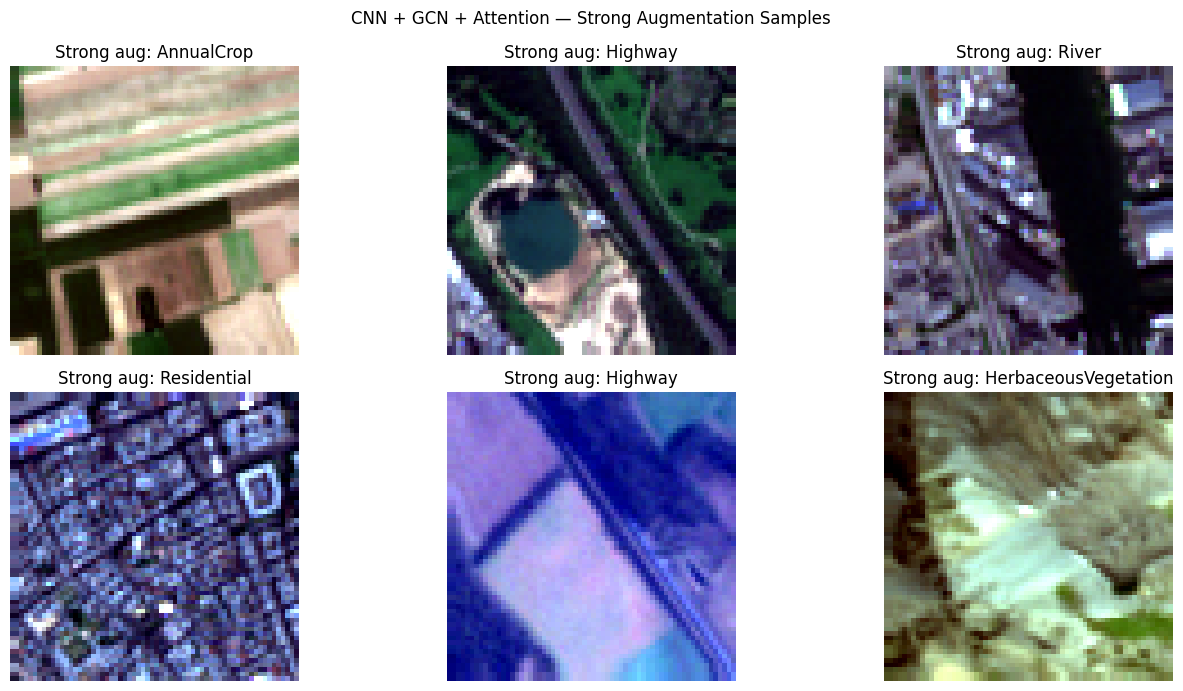

In [33]:
# ----------------------------------------------------------------
# 12.5. VERIFY AUGMENTATION SETUP
# ----------------------------------------------------------------

import matplotlib.pyplot as plt

sample_indices = np.linspace(0, len(full_dev_gcn_ds) - 1, 6, dtype=int)

plt.figure(figsize=(14, 7))
for plot_i, idx in enumerate(sample_indices, start=1):
    x, y = full_dev_gcn_ds[idx]

    # Display RGB using B04/B03/B02 (red/green/blue) when available.
    rgb = x[[BAND_RED, BAND_GREEN, BAND_BLUE]].numpy()
    rgb = np.transpose(rgb, (1, 2, 0))

    # Robust display scaling after normalization.
    lo, hi = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

    plt.subplot(2, 3, plot_i)
    plt.imshow(rgb)
    plt.title(f"Strong aug: {idx_to_label[y]}")
    plt.axis("off")

plt.suptitle("CNN + GCN + Attention — Strong Augmentation Samples")
plt.tight_layout()
plt.savefig("gcn_strong_augmentation_samples.png", dpi=150)
plt.show()


In [34]:
# ----------------------------------------------------------------
# 13. TRAINING IS PERFORMED WITH 5-FOLD CV + FINE-TUNING
# ----------------------------------------------------------------
print("CNN + GCN + Attention will be trained with 5-fold CV + final fine-tuning.")


CNN + GCN + Attention will be trained with 5-fold CV + final fine-tuning.



ResNet18 | Hyperparameter set 1/2 | {'lr': 0.0003, 'weight_decay': 0.0001}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


[ResNet18_F1_HP1] Epoch 1/8 - train_loss=0.3514 train_acc=0.8883 val_loss=0.1432 val_acc=0.9546
[ResNet18_F1_HP1] Epoch 2/8 - train_loss=0.1735 train_acc=0.9462 val_loss=0.1268 val_acc=0.9588
[ResNet18_F1_HP1] Epoch 3/8 - train_loss=0.1340 train_acc=0.9573 val_loss=0.1225 val_acc=0.9630
[ResNet18_F1_HP1] Epoch 4/8 - train_loss=0.1206 train_acc=0.9592 val_loss=0.1114 val_acc=0.9644
[ResNet18_F1_HP1] Epoch 5/8 - train_loss=0.1058 train_acc=0.9663 val_loss=0.1258 val_acc=0.9611
[ResNet18_F1_HP1] Epoch 6/8 - train_loss=0.0989 train_acc=0.9694 val_loss=0.0794 val_acc=0.9755
[ResNet18_F1_HP1] Epoch 7/8 - train_loss=0.0968 train_acc=0.9683 val_loss=0.1077 val_acc=0.9657
[ResNet18_F1_HP1] Epoch 8/8 - train_loss=0.0939 train_acc=0.9696 val_loss=0.0975 val_acc=0.9699

=== ResNet18_Fold1 — Test Set Results ===
Accuracy:  0.9755
Precision (macro): 0.9749
Recall (macro):    0.9743
F1 (macro):        0.9746

                      precision    recall  f1-score   support

          AnnualCrop       0.

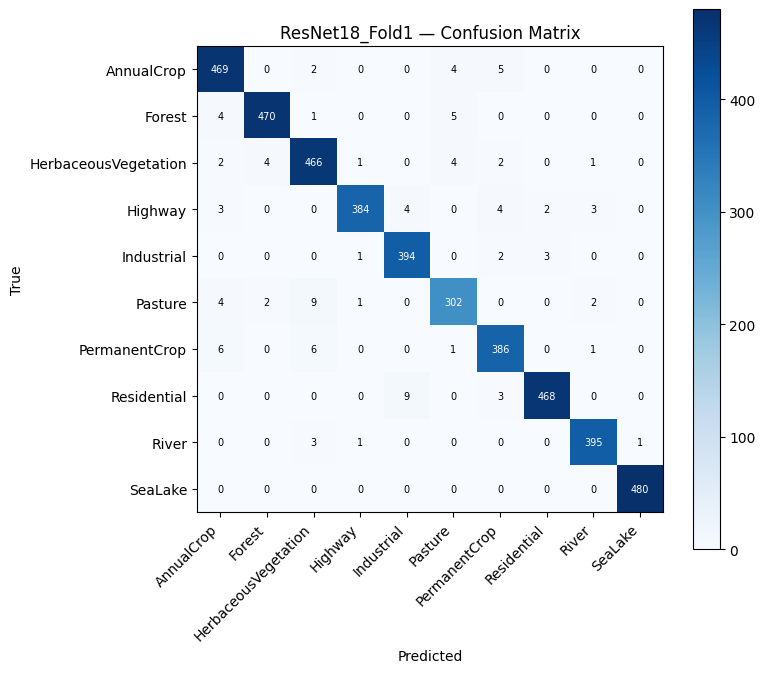

[ResNet18_F2_HP1] Epoch 1/8 - train_loss=0.3444 train_acc=0.8897 val_loss=0.1746 val_acc=0.9449
[ResNet18_F2_HP1] Epoch 2/8 - train_loss=0.1710 train_acc=0.9466 val_loss=0.1439 val_acc=0.9535
[ResNet18_F2_HP1] Epoch 3/8 - train_loss=0.1405 train_acc=0.9540 val_loss=0.1190 val_acc=0.9586
[ResNet18_F2_HP1] Epoch 4/8 - train_loss=0.1181 train_acc=0.9622 val_loss=0.0859 val_acc=0.9720
[ResNet18_F2_HP1] Epoch 5/8 - train_loss=0.1125 train_acc=0.9643 val_loss=0.0869 val_acc=0.9722
[ResNet18_F2_HP1] Epoch 6/8 - train_loss=0.0994 train_acc=0.9686 val_loss=0.0877 val_acc=0.9727
[ResNet18_F2_HP1] Epoch 7/8 - train_loss=0.0858 train_acc=0.9718 val_loss=0.0970 val_acc=0.9688
[ResNet18_F2_HP1] Early stopping at epoch 7

=== ResNet18_Fold2 — Test Set Results ===
Accuracy:  0.9720
Precision (macro): 0.9702
Recall (macro):    0.9711
F1 (macro):        0.9706

                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.96      0.97       480
              Fores

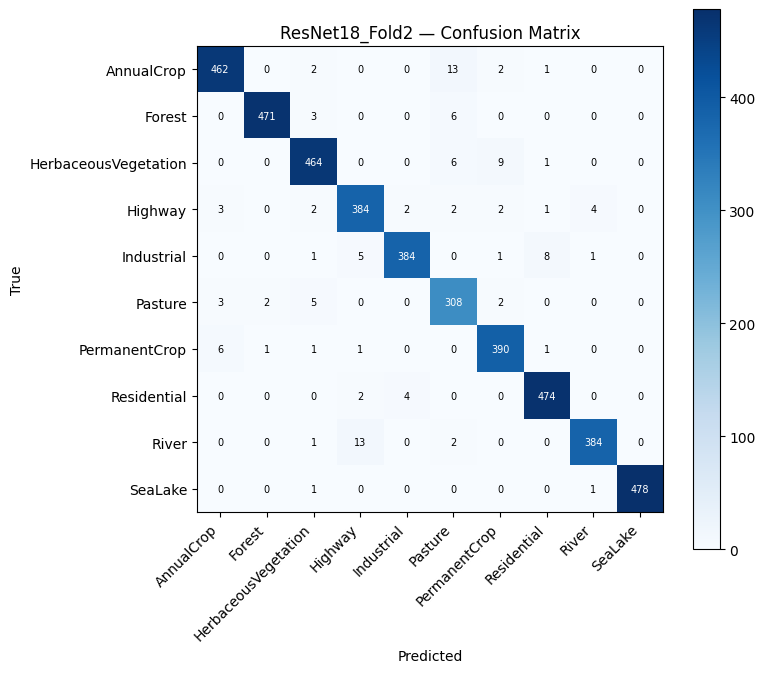

[ResNet18_F3_HP1] Epoch 1/8 - train_loss=0.3456 train_acc=0.8884 val_loss=0.1579 val_acc=0.9454
[ResNet18_F3_HP1] Epoch 2/8 - train_loss=0.1741 train_acc=0.9451 val_loss=0.1204 val_acc=0.9618
[ResNet18_F3_HP1] Epoch 3/8 - train_loss=0.1360 train_acc=0.9578 val_loss=0.1218 val_acc=0.9597
[ResNet18_F3_HP1] Epoch 4/8 - train_loss=0.1236 train_acc=0.9604 val_loss=0.1128 val_acc=0.9625
[ResNet18_F3_HP1] Epoch 5/8 - train_loss=0.1088 train_acc=0.9645 val_loss=0.1072 val_acc=0.9648
[ResNet18_F3_HP1] Epoch 6/8 - train_loss=0.0952 train_acc=0.9701 val_loss=0.1096 val_acc=0.9653
[ResNet18_F3_HP1] Epoch 7/8 - train_loss=0.0929 train_acc=0.9707 val_loss=0.1230 val_acc=0.9574
[ResNet18_F3_HP1] Epoch 8/8 - train_loss=0.0859 train_acc=0.9717 val_loss=0.1029 val_acc=0.9655

=== ResNet18_Fold3 — Test Set Results ===
Accuracy:  0.9655
Precision (macro): 0.9659
Recall (macro):    0.9623
F1 (macro):        0.9636

                      precision    recall  f1-score   support

          AnnualCrop       0.

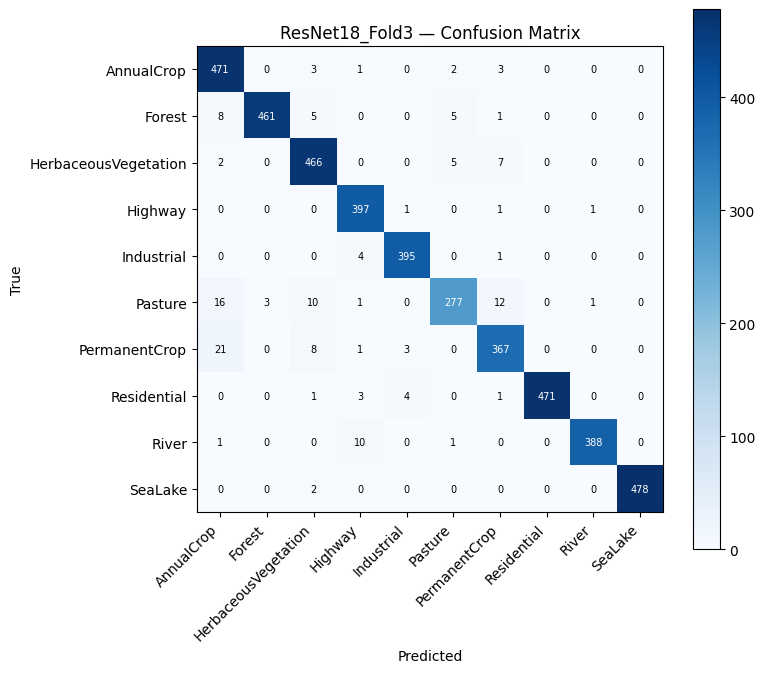

[ResNet18_F4_HP1] Epoch 1/8 - train_loss=0.3512 train_acc=0.8872 val_loss=0.1788 val_acc=0.9468
[ResNet18_F4_HP1] Epoch 2/8 - train_loss=0.1816 train_acc=0.9409 val_loss=0.1267 val_acc=0.9620
[ResNet18_F4_HP1] Epoch 3/8 - train_loss=0.1392 train_acc=0.9541 val_loss=0.1038 val_acc=0.9685
[ResNet18_F4_HP1] Epoch 4/8 - train_loss=0.1216 train_acc=0.9591 val_loss=0.1074 val_acc=0.9674
[ResNet18_F4_HP1] Epoch 5/8 - train_loss=0.1210 train_acc=0.9606 val_loss=0.0966 val_acc=0.9694
[ResNet18_F4_HP1] Epoch 6/8 - train_loss=0.1073 train_acc=0.9653 val_loss=0.0953 val_acc=0.9664
[ResNet18_F4_HP1] Epoch 7/8 - train_loss=0.1009 train_acc=0.9682 val_loss=0.1014 val_acc=0.9630
[ResNet18_F4_HP1] Epoch 8/8 - train_loss=0.0971 train_acc=0.9673 val_loss=0.0866 val_acc=0.9731

=== ResNet18_Fold4 — Test Set Results ===
Accuracy:  0.9731
Precision (macro): 0.9730
Recall (macro):    0.9721
F1 (macro):        0.9724

                      precision    recall  f1-score   support

          AnnualCrop       0.

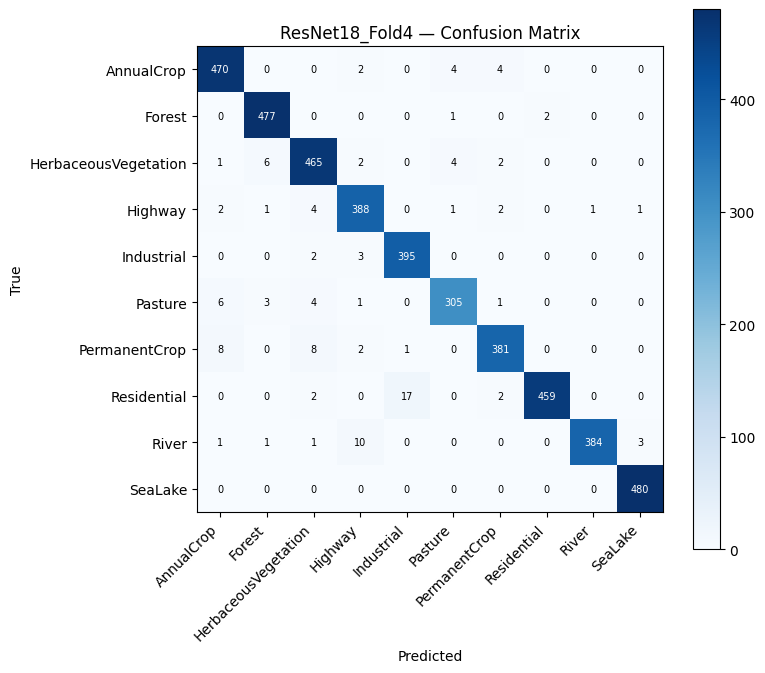

[ResNet18_F5_HP1] Epoch 1/8 - train_loss=0.3567 train_acc=0.8899 val_loss=0.1493 val_acc=0.9498
[ResNet18_F5_HP1] Epoch 2/8 - train_loss=0.1760 train_acc=0.9421 val_loss=0.1164 val_acc=0.9630
[ResNet18_F5_HP1] Epoch 3/8 - train_loss=0.1397 train_acc=0.9538 val_loss=0.1292 val_acc=0.9576
[ResNet18_F5_HP1] Epoch 4/8 - train_loss=0.1174 train_acc=0.9631 val_loss=0.0974 val_acc=0.9671
[ResNet18_F5_HP1] Epoch 5/8 - train_loss=0.1084 train_acc=0.9648 val_loss=0.1046 val_acc=0.9688
[ResNet18_F5_HP1] Epoch 6/8 - train_loss=0.1020 train_acc=0.9674 val_loss=0.0780 val_acc=0.9750
[ResNet18_F5_HP1] Epoch 7/8 - train_loss=0.0934 train_acc=0.9689 val_loss=0.0743 val_acc=0.9778
[ResNet18_F5_HP1] Epoch 8/8 - train_loss=0.0826 train_acc=0.9736 val_loss=0.0772 val_acc=0.9769

=== ResNet18_Fold5 — Test Set Results ===
Accuracy:  0.9778
Precision (macro): 0.9768
Recall (macro):    0.9780
F1 (macro):        0.9773

                      precision    recall  f1-score   support

          AnnualCrop       0.

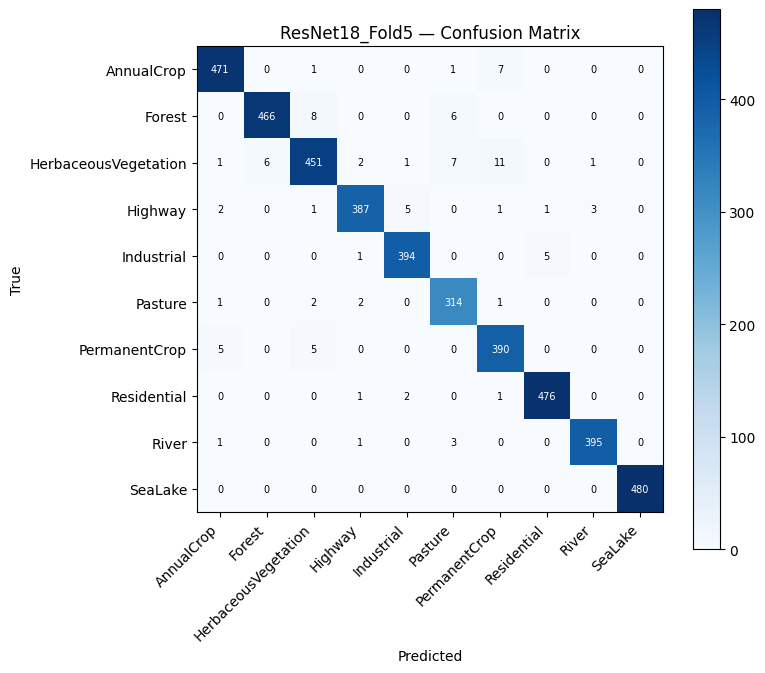

ResNet18 HP1: mean_acc=0.9728 ± 0.0041, mean_f1=0.9717

ResNet18 | Hyperparameter set 2/2 | {'lr': 0.0001, 'weight_decay': 0.0001}
[ResNet18_F1_HP2] Epoch 1/8 - train_loss=0.4414 train_acc=0.8591 val_loss=0.1703 val_acc=0.9449
[ResNet18_F1_HP2] Epoch 2/8 - train_loss=0.1669 train_acc=0.9446 val_loss=0.1270 val_acc=0.9595
[ResNet18_F1_HP2] Epoch 3/8 - train_loss=0.1334 train_acc=0.9576 val_loss=0.0895 val_acc=0.9738
[ResNet18_F1_HP2] Epoch 4/8 - train_loss=0.1016 train_acc=0.9673 val_loss=0.0941 val_acc=0.9699
[ResNet18_F1_HP2] Epoch 5/8 - train_loss=0.0972 train_acc=0.9679 val_loss=0.1019 val_acc=0.9694
[ResNet18_F1_HP2] Epoch 6/8 - train_loss=0.0793 train_acc=0.9750 val_loss=0.0806 val_acc=0.9727
[ResNet18_F1_HP2] Epoch 7/8 - train_loss=0.0721 train_acc=0.9769 val_loss=0.0782 val_acc=0.9762
[ResNet18_F1_HP2] Epoch 8/8 - train_loss=0.0629 train_acc=0.9786 val_loss=0.0835 val_acc=0.9759

=== ResNet18_Fold1 — Test Set Results ===
Accuracy:  0.9762
Precision (macro): 0.9760
Recall (macro)

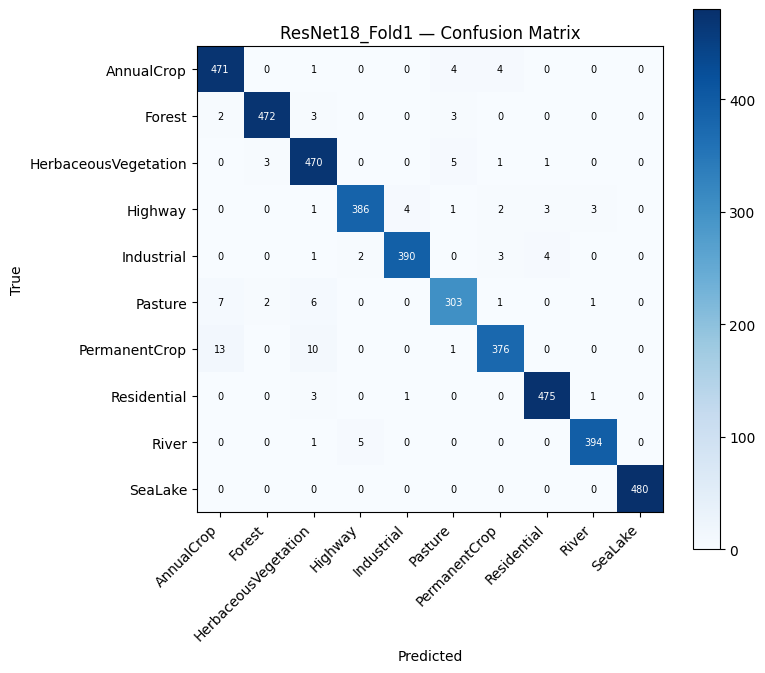

[ResNet18_F2_HP2] Epoch 1/8 - train_loss=0.4309 train_acc=0.8617 val_loss=0.1399 val_acc=0.9560
[ResNet18_F2_HP2] Epoch 2/8 - train_loss=0.1688 train_acc=0.9444 val_loss=0.1190 val_acc=0.9613
[ResNet18_F2_HP2] Epoch 3/8 - train_loss=0.1319 train_acc=0.9579 val_loss=0.0895 val_acc=0.9701
[ResNet18_F2_HP2] Epoch 4/8 - train_loss=0.1028 train_acc=0.9655 val_loss=0.0806 val_acc=0.9729
[ResNet18_F2_HP2] Epoch 5/8 - train_loss=0.0879 train_acc=0.9714 val_loss=0.0698 val_acc=0.9748
[ResNet18_F2_HP2] Epoch 6/8 - train_loss=0.0829 train_acc=0.9734 val_loss=0.0825 val_acc=0.9729
[ResNet18_F2_HP2] Epoch 7/8 - train_loss=0.0728 train_acc=0.9757 val_loss=0.0670 val_acc=0.9780
[ResNet18_F2_HP2] Epoch 8/8 - train_loss=0.0687 train_acc=0.9764 val_loss=0.0718 val_acc=0.9755

=== ResNet18_Fold2 — Test Set Results ===
Accuracy:  0.9780
Precision (macro): 0.9779
Recall (macro):    0.9763
F1 (macro):        0.9770

                      precision    recall  f1-score   support

          AnnualCrop       0.

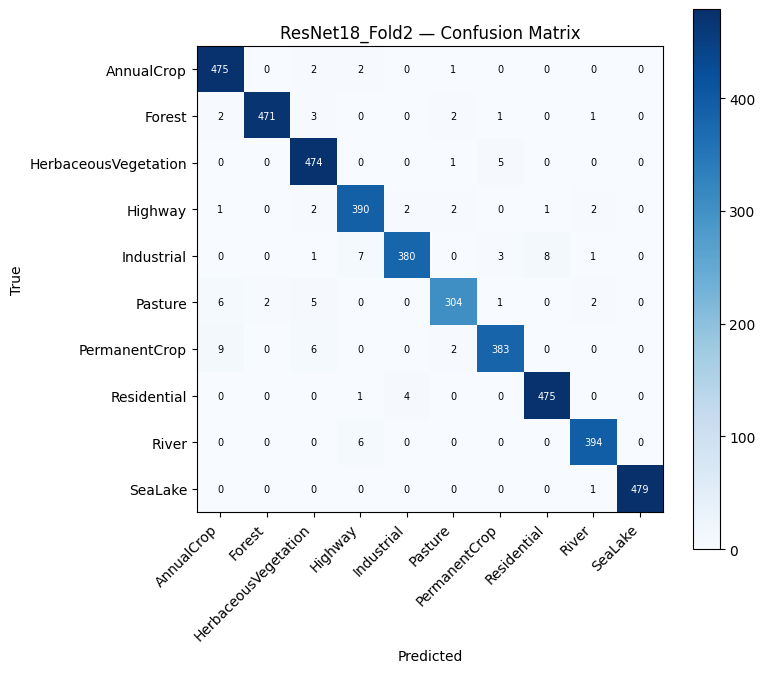

[ResNet18_F3_HP2] Epoch 1/8 - train_loss=0.4466 train_acc=0.8584 val_loss=0.1883 val_acc=0.9391
[ResNet18_F3_HP2] Epoch 2/8 - train_loss=0.1712 train_acc=0.9434 val_loss=0.1351 val_acc=0.9523
[ResNet18_F3_HP2] Epoch 3/8 - train_loss=0.1309 train_acc=0.9582 val_loss=0.1271 val_acc=0.9581
[ResNet18_F3_HP2] Epoch 4/8 - train_loss=0.1161 train_acc=0.9620 val_loss=0.1043 val_acc=0.9660
[ResNet18_F3_HP2] Epoch 5/8 - train_loss=0.0942 train_acc=0.9690 val_loss=0.0829 val_acc=0.9718
[ResNet18_F3_HP2] Epoch 6/8 - train_loss=0.0793 train_acc=0.9729 val_loss=0.1045 val_acc=0.9646
[ResNet18_F3_HP2] Epoch 7/8 - train_loss=0.0775 train_acc=0.9749 val_loss=0.0803 val_acc=0.9731
[ResNet18_F3_HP2] Epoch 8/8 - train_loss=0.0674 train_acc=0.9773 val_loss=0.0789 val_acc=0.9750

=== ResNet18_Fold3 — Test Set Results ===
Accuracy:  0.9750
Precision (macro): 0.9748
Recall (macro):    0.9730
F1 (macro):        0.9737

                      precision    recall  f1-score   support

          AnnualCrop       0.

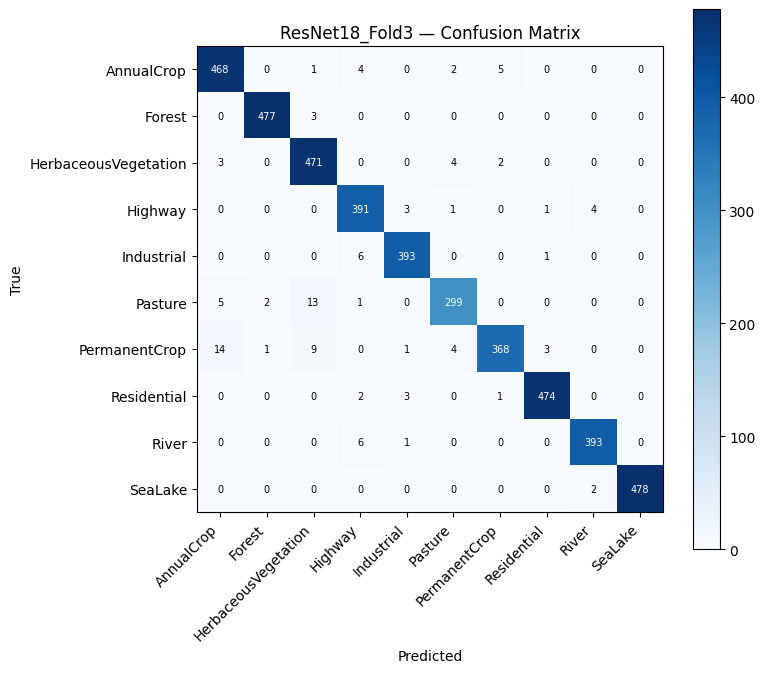

[ResNet18_F4_HP2] Epoch 1/8 - train_loss=0.4606 train_acc=0.8547 val_loss=0.1374 val_acc=0.9530
[ResNet18_F4_HP2] Epoch 2/8 - train_loss=0.1779 train_acc=0.9422 val_loss=0.1171 val_acc=0.9620
[ResNet18_F4_HP2] Epoch 3/8 - train_loss=0.1352 train_acc=0.9565 val_loss=0.0994 val_acc=0.9664
[ResNet18_F4_HP2] Epoch 4/8 - train_loss=0.1008 train_acc=0.9670 val_loss=0.0998 val_acc=0.9683
[ResNet18_F4_HP2] Epoch 5/8 - train_loss=0.0986 train_acc=0.9655 val_loss=0.0876 val_acc=0.9720
[ResNet18_F4_HP2] Epoch 6/8 - train_loss=0.0903 train_acc=0.9704 val_loss=0.0779 val_acc=0.9750
[ResNet18_F4_HP2] Epoch 7/8 - train_loss=0.0810 train_acc=0.9720 val_loss=0.0684 val_acc=0.9787
[ResNet18_F4_HP2] Epoch 8/8 - train_loss=0.0630 train_acc=0.9785 val_loss=0.0696 val_acc=0.9785

=== ResNet18_Fold4 — Test Set Results ===
Accuracy:  0.9787
Precision (macro): 0.9787
Recall (macro):    0.9774
F1 (macro):        0.9779

                      precision    recall  f1-score   support

          AnnualCrop       0.

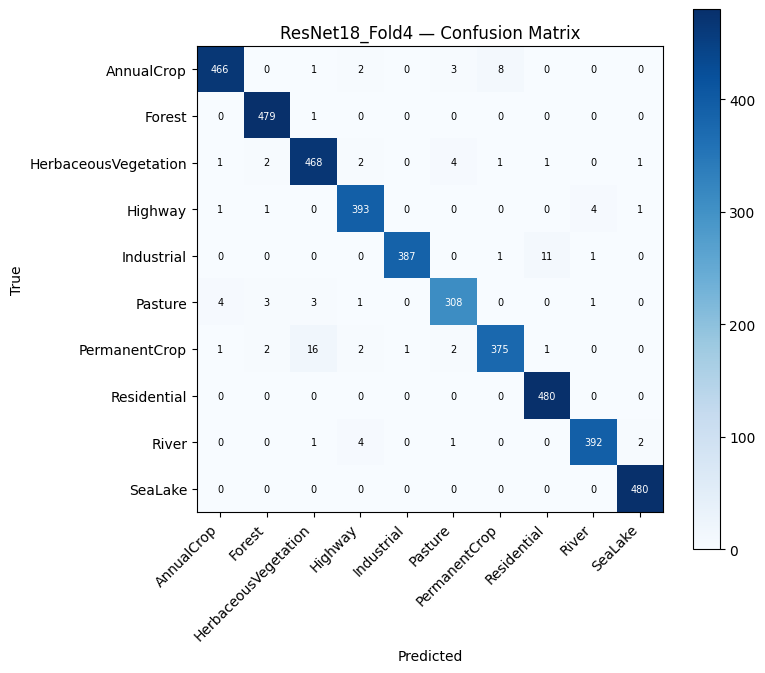

[ResNet18_F5_HP2] Epoch 1/8 - train_loss=0.4425 train_acc=0.8578 val_loss=0.1398 val_acc=0.9516
[ResNet18_F5_HP2] Epoch 2/8 - train_loss=0.1655 train_acc=0.9445 val_loss=0.1308 val_acc=0.9542
[ResNet18_F5_HP2] Epoch 3/8 - train_loss=0.1340 train_acc=0.9575 val_loss=0.0900 val_acc=0.9708
[ResNet18_F5_HP2] Epoch 4/8 - train_loss=0.1105 train_acc=0.9629 val_loss=0.1106 val_acc=0.9632
[ResNet18_F5_HP2] Epoch 5/8 - train_loss=0.0951 train_acc=0.9682 val_loss=0.0709 val_acc=0.9762
[ResNet18_F5_HP2] Epoch 6/8 - train_loss=0.0828 train_acc=0.9723 val_loss=0.0684 val_acc=0.9750
[ResNet18_F5_HP2] Epoch 7/8 - train_loss=0.0706 train_acc=0.9760 val_loss=0.0769 val_acc=0.9745
[ResNet18_F5_HP2] Epoch 8/8 - train_loss=0.0639 train_acc=0.9778 val_loss=0.0833 val_acc=0.9757

=== ResNet18_Fold5 — Test Set Results ===
Accuracy:  0.9750
Precision (macro): 0.9746
Recall (macro):    0.9738
F1 (macro):        0.9741

                      precision    recall  f1-score   support

          AnnualCrop       0.

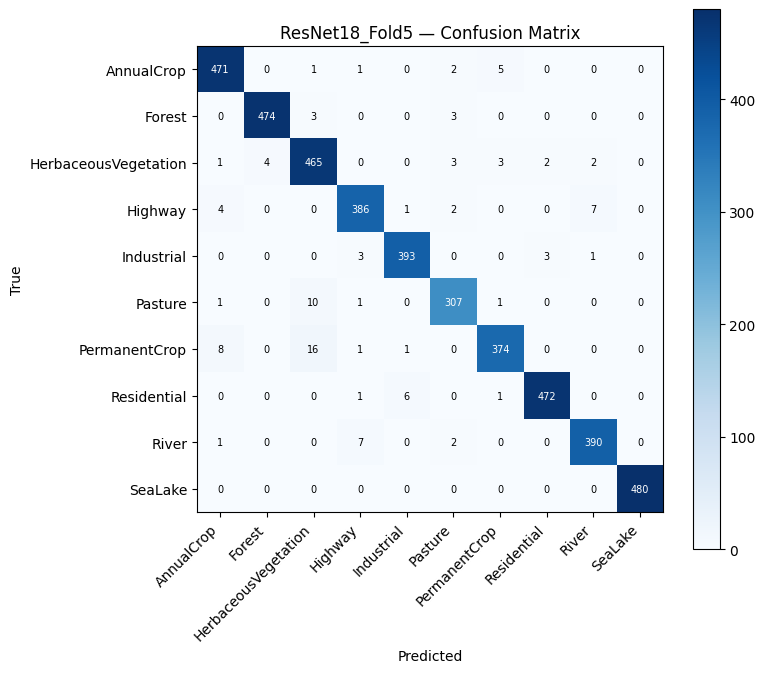

ResNet18 HP2: mean_acc=0.9766 ± 0.0015, mean_f1=0.9756

CNN_GCN_Attention | Hyperparameter set 1/3 | {'lr': 0.0003, 'weight_decay': 0.0001, 'dropout': 0.25}
[CNN_GCN_Attention_F1_HP1] Epoch 1/8 - train_loss=0.9164 train_acc=0.7333 val_loss=0.4125 val_acc=0.8808
[CNN_GCN_Attention_F1_HP1] Epoch 2/8 - train_loss=0.4488 train_acc=0.8640 val_loss=0.2505 val_acc=0.9245
[CNN_GCN_Attention_F1_HP1] Epoch 3/8 - train_loss=0.3542 train_acc=0.8942 val_loss=0.2410 val_acc=0.9241
[CNN_GCN_Attention_F1_HP1] Epoch 4/8 - train_loss=0.3157 train_acc=0.9027 val_loss=0.1880 val_acc=0.9437
[CNN_GCN_Attention_F1_HP1] Epoch 5/8 - train_loss=0.2748 train_acc=0.9161 val_loss=0.2202 val_acc=0.9259
[CNN_GCN_Attention_F1_HP1] Epoch 6/8 - train_loss=0.2592 train_acc=0.9201 val_loss=0.1354 val_acc=0.9560
[CNN_GCN_Attention_F1_HP1] Epoch 7/8 - train_loss=0.2346 train_acc=0.9285 val_loss=0.1861 val_acc=0.9356
[CNN_GCN_Attention_F1_HP1] Epoch 8/8 - train_loss=0.2332 train_acc=0.9266 val_loss=0.1402 val_acc=0.9560

==

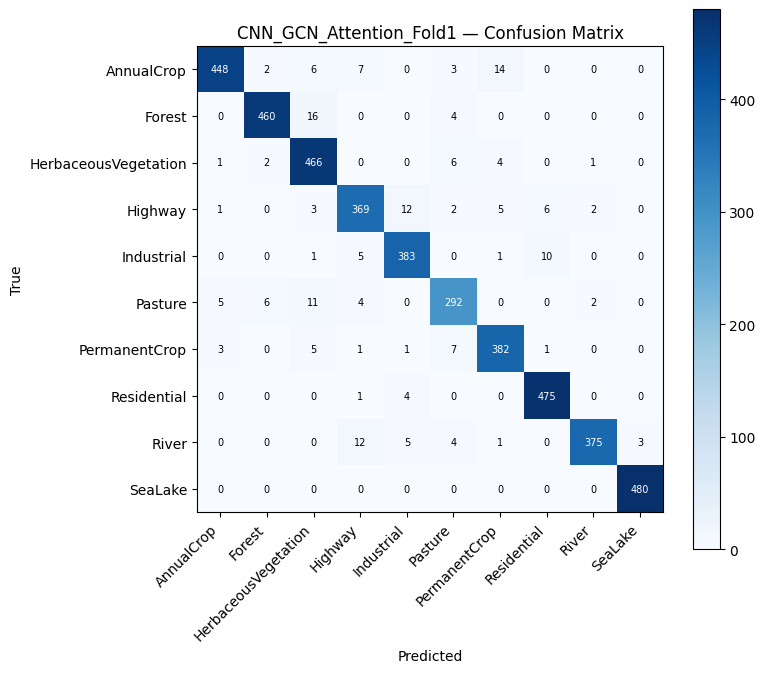

[CNN_GCN_Attention_F2_HP1] Epoch 1/8 - train_loss=0.8755 train_acc=0.7494 val_loss=0.4229 val_acc=0.8660
[CNN_GCN_Attention_F2_HP1] Epoch 2/8 - train_loss=0.4438 train_acc=0.8658 val_loss=0.2639 val_acc=0.9169
[CNN_GCN_Attention_F2_HP1] Epoch 3/8 - train_loss=0.3424 train_acc=0.8962 val_loss=0.2124 val_acc=0.9336
[CNN_GCN_Attention_F2_HP1] Epoch 4/8 - train_loss=0.2944 train_acc=0.9093 val_loss=0.2009 val_acc=0.9343
[CNN_GCN_Attention_F2_HP1] Epoch 5/8 - train_loss=0.2748 train_acc=0.9136 val_loss=0.2081 val_acc=0.9324
[CNN_GCN_Attention_F2_HP1] Epoch 6/8 - train_loss=0.2388 train_acc=0.9260 val_loss=0.2118 val_acc=0.9308
[CNN_GCN_Attention_F2_HP1] Epoch 7/8 - train_loss=0.2358 train_acc=0.9278 val_loss=0.1413 val_acc=0.9528
[CNN_GCN_Attention_F2_HP1] Epoch 8/8 - train_loss=0.2224 train_acc=0.9315 val_loss=0.1685 val_acc=0.9463

=== CNN_GCN_Attention_Fold2 — Test Set Results ===
Accuracy:  0.9528
Precision (macro): 0.9527
Recall (macro):    0.9496
F1 (macro):        0.9505

           

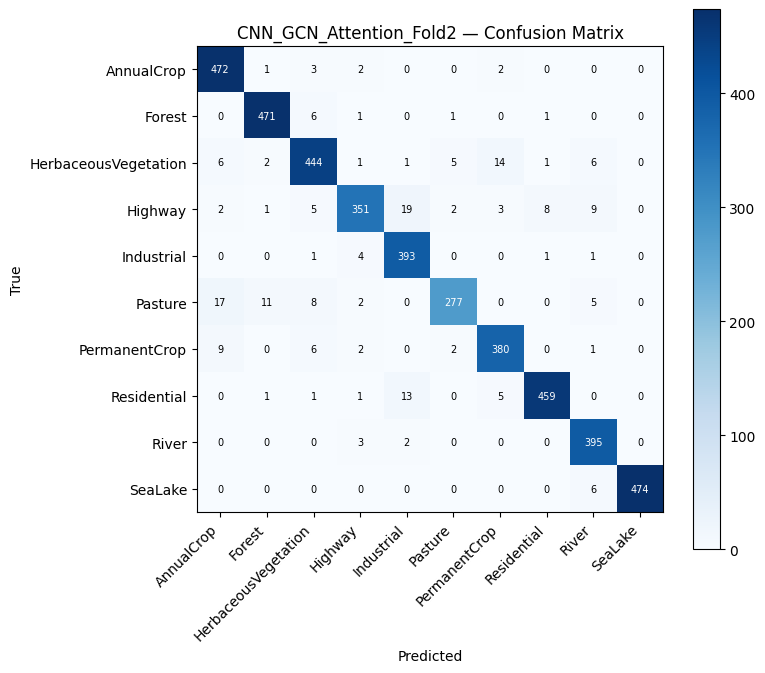

[CNN_GCN_Attention_F3_HP1] Epoch 1/8 - train_loss=0.8871 train_acc=0.7389 val_loss=0.4133 val_acc=0.8676
[CNN_GCN_Attention_F3_HP1] Epoch 2/8 - train_loss=0.4391 train_acc=0.8656 val_loss=0.2999 val_acc=0.9002
[CNN_GCN_Attention_F3_HP1] Epoch 3/8 - train_loss=0.3647 train_acc=0.8887 val_loss=0.2638 val_acc=0.9150
[CNN_GCN_Attention_F3_HP1] Epoch 4/8 - train_loss=0.3177 train_acc=0.9016 val_loss=0.2160 val_acc=0.9356
[CNN_GCN_Attention_F3_HP1] Epoch 5/8 - train_loss=0.2585 train_acc=0.9198 val_loss=0.2510 val_acc=0.9171
[CNN_GCN_Attention_F3_HP1] Epoch 6/8 - train_loss=0.2640 train_acc=0.9201 val_loss=0.1799 val_acc=0.9426
[CNN_GCN_Attention_F3_HP1] Epoch 7/8 - train_loss=0.2235 train_acc=0.9313 val_loss=0.1982 val_acc=0.9329
[CNN_GCN_Attention_F3_HP1] Epoch 8/8 - train_loss=0.2078 train_acc=0.9357 val_loss=0.1608 val_acc=0.9479

=== CNN_GCN_Attention_Fold3 — Test Set Results ===
Accuracy:  0.9479
Precision (macro): 0.9501
Recall (macro):    0.9450
F1 (macro):        0.9462

           

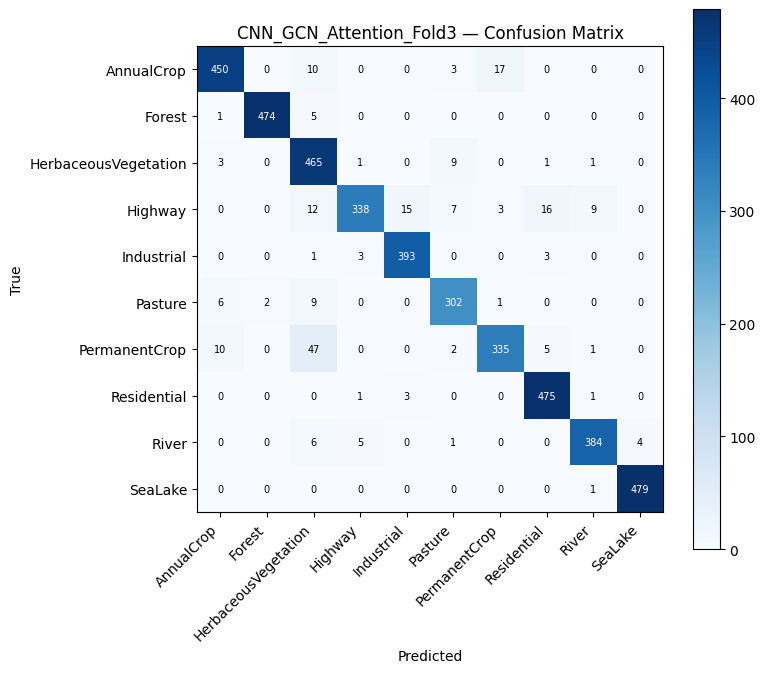

[CNN_GCN_Attention_F4_HP1] Epoch 1/8 - train_loss=0.8588 train_acc=0.7584 val_loss=0.4594 val_acc=0.8502
[CNN_GCN_Attention_F4_HP1] Epoch 2/8 - train_loss=0.4372 train_acc=0.8702 val_loss=0.2785 val_acc=0.9125
[CNN_GCN_Attention_F4_HP1] Epoch 3/8 - train_loss=0.3495 train_acc=0.8942 val_loss=0.2050 val_acc=0.9375
[CNN_GCN_Attention_F4_HP1] Epoch 4/8 - train_loss=0.3031 train_acc=0.9066 val_loss=0.1935 val_acc=0.9396
[CNN_GCN_Attention_F4_HP1] Epoch 5/8 - train_loss=0.2702 train_acc=0.9181 val_loss=0.2437 val_acc=0.9220
[CNN_GCN_Attention_F4_HP1] Epoch 6/8 - train_loss=0.2546 train_acc=0.9204 val_loss=0.1580 val_acc=0.9507
[CNN_GCN_Attention_F4_HP1] Epoch 7/8 - train_loss=0.2374 train_acc=0.9277 val_loss=0.1520 val_acc=0.9519
[CNN_GCN_Attention_F4_HP1] Epoch 8/8 - train_loss=0.2070 train_acc=0.9359 val_loss=0.1454 val_acc=0.9563

=== CNN_GCN_Attention_Fold4 — Test Set Results ===
Accuracy:  0.9563
Precision (macro): 0.9552
Recall (macro):    0.9544
F1 (macro):        0.9545

           

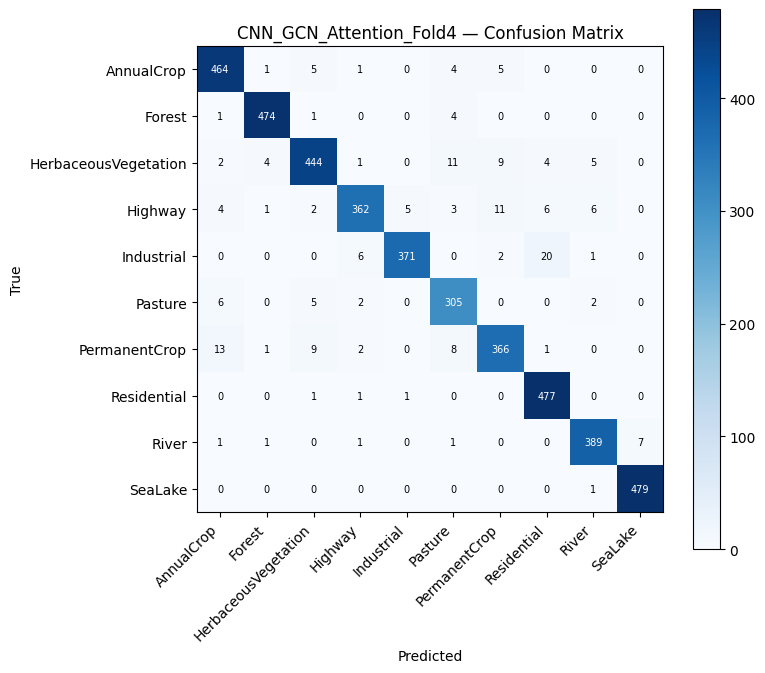

[CNN_GCN_Attention_F5_HP1] Epoch 1/8 - train_loss=0.8743 train_acc=0.7422 val_loss=0.4151 val_acc=0.8639
[CNN_GCN_Attention_F5_HP1] Epoch 2/8 - train_loss=0.4512 train_acc=0.8641 val_loss=0.2469 val_acc=0.9231
[CNN_GCN_Attention_F5_HP1] Epoch 3/8 - train_loss=0.3569 train_acc=0.8900 val_loss=0.2106 val_acc=0.9331
[CNN_GCN_Attention_F5_HP1] Epoch 4/8 - train_loss=0.3068 train_acc=0.9065 val_loss=0.1984 val_acc=0.9352
[CNN_GCN_Attention_F5_HP1] Epoch 5/8 - train_loss=0.2829 train_acc=0.9126 val_loss=0.2428 val_acc=0.9208
[CNN_GCN_Attention_F5_HP1] Epoch 6/8 - train_loss=0.2487 train_acc=0.9248 val_loss=0.1885 val_acc=0.9377
[CNN_GCN_Attention_F5_HP1] Epoch 7/8 - train_loss=0.2335 train_acc=0.9295 val_loss=0.1727 val_acc=0.9461
[CNN_GCN_Attention_F5_HP1] Epoch 8/8 - train_loss=0.2244 train_acc=0.9304 val_loss=0.1750 val_acc=0.9428

=== CNN_GCN_Attention_Fold5 — Test Set Results ===
Accuracy:  0.9461
Precision (macro): 0.9463
Recall (macro):    0.9444
F1 (macro):        0.9447

           

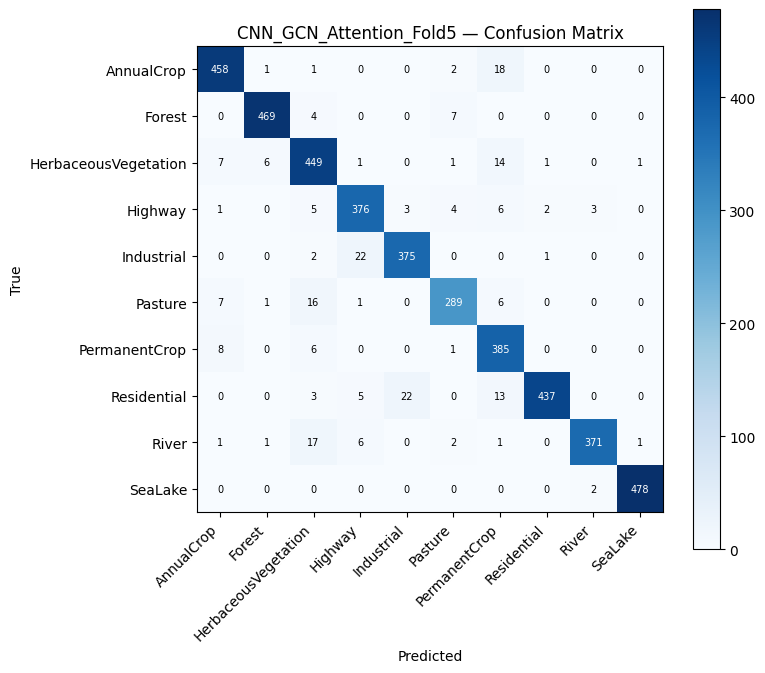

CNN_GCN_Attention HP1: mean_acc=0.9518 ± 0.0042, mean_f1=0.9500

CNN_GCN_Attention | Hyperparameter set 2/3 | {'lr': 0.0001, 'weight_decay': 0.0001, 'dropout': 0.35}
[CNN_GCN_Attention_F1_HP2] Epoch 1/8 - train_loss=1.2826 train_acc=0.6525 val_loss=0.5725 val_acc=0.8718
[CNN_GCN_Attention_F1_HP2] Epoch 2/8 - train_loss=0.6147 train_acc=0.8406 val_loss=0.3325 val_acc=0.9028
[CNN_GCN_Attention_F1_HP2] Epoch 3/8 - train_loss=0.4381 train_acc=0.8807 val_loss=0.2300 val_acc=0.9310
[CNN_GCN_Attention_F1_HP2] Epoch 4/8 - train_loss=0.3699 train_acc=0.8969 val_loss=0.2014 val_acc=0.9375
[CNN_GCN_Attention_F1_HP2] Epoch 5/8 - train_loss=0.3204 train_acc=0.9072 val_loss=0.1735 val_acc=0.9481
[CNN_GCN_Attention_F1_HP2] Epoch 6/8 - train_loss=0.2918 train_acc=0.9155 val_loss=0.1648 val_acc=0.9523
[CNN_GCN_Attention_F1_HP2] Epoch 7/8 - train_loss=0.2680 train_acc=0.9227 val_loss=0.1690 val_acc=0.9481
[CNN_GCN_Attention_F1_HP2] Epoch 8/8 - train_loss=0.2440 train_acc=0.9302 val_loss=0.1509 val_acc=0

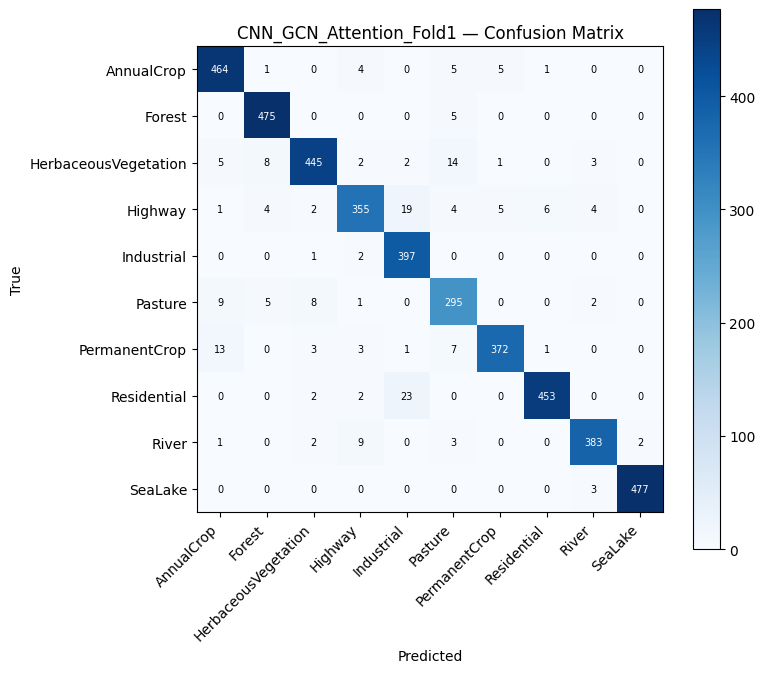

[CNN_GCN_Attention_F2_HP2] Epoch 1/8 - train_loss=1.2601 train_acc=0.6510 val_loss=0.5754 val_acc=0.8481
[CNN_GCN_Attention_F2_HP2] Epoch 2/8 - train_loss=0.6062 train_acc=0.8406 val_loss=0.3199 val_acc=0.9132
[CNN_GCN_Attention_F2_HP2] Epoch 3/8 - train_loss=0.4391 train_acc=0.8786 val_loss=0.2446 val_acc=0.9241
[CNN_GCN_Attention_F2_HP2] Epoch 4/8 - train_loss=0.3725 train_acc=0.8964 val_loss=0.2255 val_acc=0.9333
[CNN_GCN_Attention_F2_HP2] Epoch 5/8 - train_loss=0.3106 train_acc=0.9108 val_loss=0.1664 val_acc=0.9479
[CNN_GCN_Attention_F2_HP2] Epoch 6/8 - train_loss=0.2861 train_acc=0.9184 val_loss=0.1480 val_acc=0.9551
[CNN_GCN_Attention_F2_HP2] Epoch 7/8 - train_loss=0.2578 train_acc=0.9259 val_loss=0.1469 val_acc=0.9535
[CNN_GCN_Attention_F2_HP2] Epoch 8/8 - train_loss=0.2492 train_acc=0.9301 val_loss=0.1254 val_acc=0.9572

=== CNN_GCN_Attention_Fold2 — Test Set Results ===
Accuracy:  0.9572
Precision (macro): 0.9561
Recall (macro):    0.9552
F1 (macro):        0.9556

           

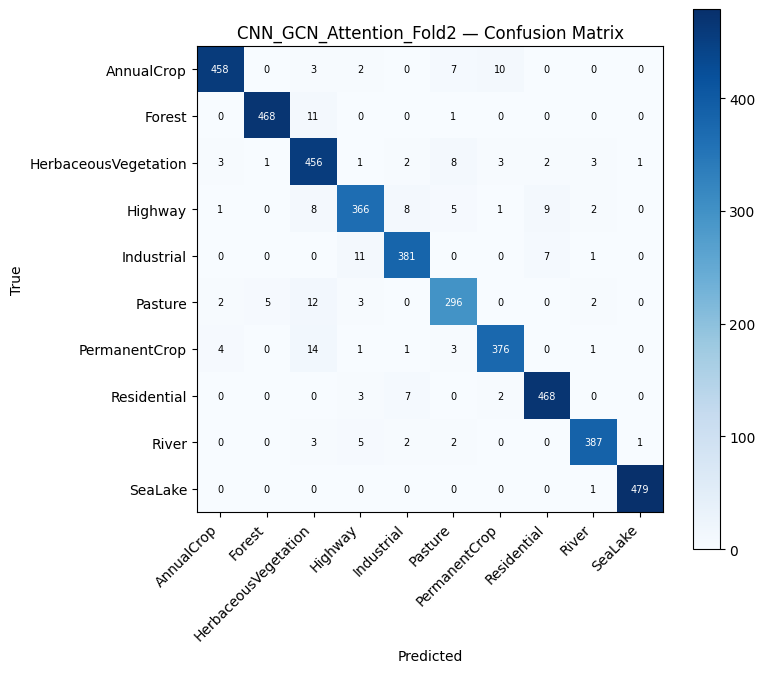

[CNN_GCN_Attention_F3_HP2] Epoch 1/8 - train_loss=1.2699 train_acc=0.6455 val_loss=0.5747 val_acc=0.8525
[CNN_GCN_Attention_F3_HP2] Epoch 2/8 - train_loss=0.5929 train_acc=0.8470 val_loss=0.3070 val_acc=0.9106
[CNN_GCN_Attention_F3_HP2] Epoch 3/8 - train_loss=0.4280 train_acc=0.8806 val_loss=0.2519 val_acc=0.9241
[CNN_GCN_Attention_F3_HP2] Epoch 4/8 - train_loss=0.3420 train_acc=0.9049 val_loss=0.2312 val_acc=0.9250
[CNN_GCN_Attention_F3_HP2] Epoch 5/8 - train_loss=0.3094 train_acc=0.9128 val_loss=0.1591 val_acc=0.9509
[CNN_GCN_Attention_F3_HP2] Epoch 6/8 - train_loss=0.2714 train_acc=0.9230 val_loss=0.1628 val_acc=0.9523
[CNN_GCN_Attention_F3_HP2] Epoch 7/8 - train_loss=0.2462 train_acc=0.9311 val_loss=0.1476 val_acc=0.9519
[CNN_GCN_Attention_F3_HP2] Epoch 8/8 - train_loss=0.2301 train_acc=0.9366 val_loss=0.1226 val_acc=0.9613

=== CNN_GCN_Attention_Fold3 — Test Set Results ===
Accuracy:  0.9613
Precision (macro): 0.9600
Recall (macro):    0.9597
F1 (macro):        0.9597

           

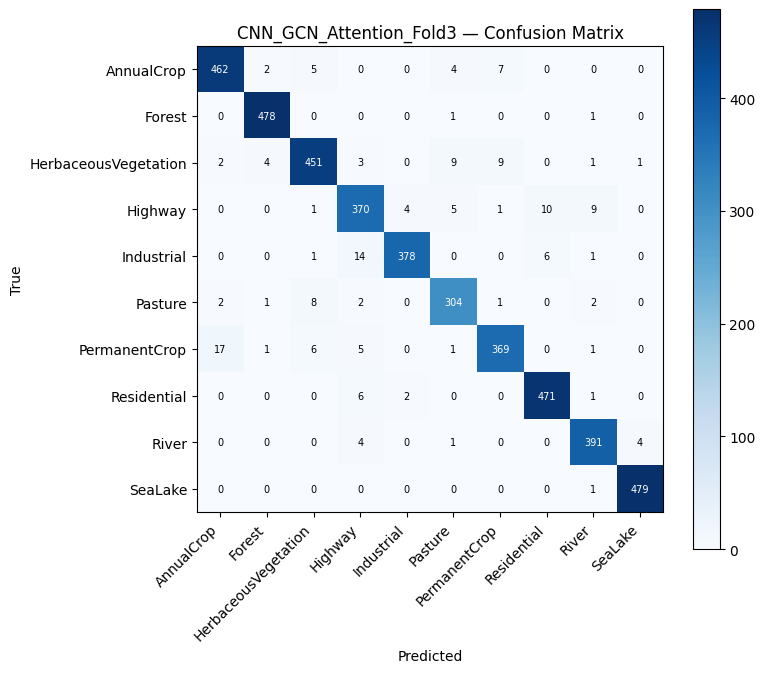

[CNN_GCN_Attention_F4_HP2] Epoch 1/8 - train_loss=1.2629 train_acc=0.6425 val_loss=0.6079 val_acc=0.8417
[CNN_GCN_Attention_F4_HP2] Epoch 2/8 - train_loss=0.6438 train_acc=0.8259 val_loss=0.3803 val_acc=0.8924
[CNN_GCN_Attention_F4_HP2] Epoch 3/8 - train_loss=0.4773 train_acc=0.8667 val_loss=0.2994 val_acc=0.9088
[CNN_GCN_Attention_F4_HP2] Epoch 4/8 - train_loss=0.3833 train_acc=0.8904 val_loss=0.2252 val_acc=0.9310
[CNN_GCN_Attention_F4_HP2] Epoch 5/8 - train_loss=0.3324 train_acc=0.9071 val_loss=0.2241 val_acc=0.9296
[CNN_GCN_Attention_F4_HP2] Epoch 6/8 - train_loss=0.2922 train_acc=0.9156 val_loss=0.1679 val_acc=0.9472
[CNN_GCN_Attention_F4_HP2] Epoch 7/8 - train_loss=0.2739 train_acc=0.9216 val_loss=0.1792 val_acc=0.9451
[CNN_GCN_Attention_F4_HP2] Epoch 8/8 - train_loss=0.2593 train_acc=0.9251 val_loss=0.1433 val_acc=0.9553

=== CNN_GCN_Attention_Fold4 — Test Set Results ===
Accuracy:  0.9553
Precision (macro): 0.9538
Recall (macro):    0.9531
F1 (macro):        0.9530

           

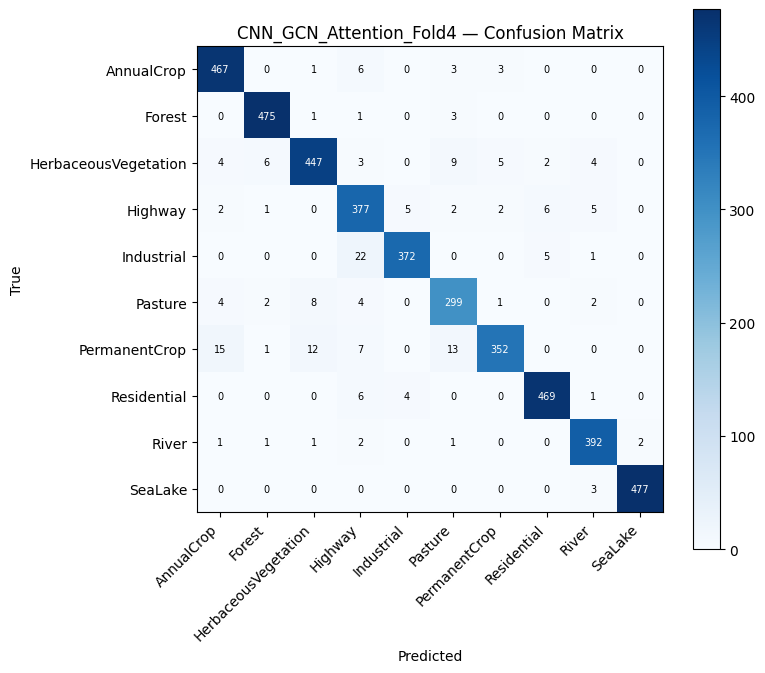

[CNN_GCN_Attention_F5_HP2] Epoch 1/8 - train_loss=1.2690 train_acc=0.6506 val_loss=0.5641 val_acc=0.8734
[CNN_GCN_Attention_F5_HP2] Epoch 2/8 - train_loss=0.6080 train_acc=0.8406 val_loss=0.3370 val_acc=0.8993
[CNN_GCN_Attention_F5_HP2] Epoch 3/8 - train_loss=0.4432 train_acc=0.8763 val_loss=0.2669 val_acc=0.9169
[CNN_GCN_Attention_F5_HP2] Epoch 4/8 - train_loss=0.3563 train_acc=0.9013 val_loss=0.2111 val_acc=0.9326
[CNN_GCN_Attention_F5_HP2] Epoch 5/8 - train_loss=0.3283 train_acc=0.9073 val_loss=0.2205 val_acc=0.9264
[CNN_GCN_Attention_F5_HP2] Epoch 6/8 - train_loss=0.2783 train_acc=0.9196 val_loss=0.1486 val_acc=0.9542
[CNN_GCN_Attention_F5_HP2] Epoch 7/8 - train_loss=0.2568 train_acc=0.9268 val_loss=0.1824 val_acc=0.9417
[CNN_GCN_Attention_F5_HP2] Epoch 8/8 - train_loss=0.2360 train_acc=0.9318 val_loss=0.1399 val_acc=0.9546

=== CNN_GCN_Attention_Fold5 — Test Set Results ===
Accuracy:  0.9546
Precision (macro): 0.9533
Recall (macro):    0.9521
F1 (macro):        0.9524

           

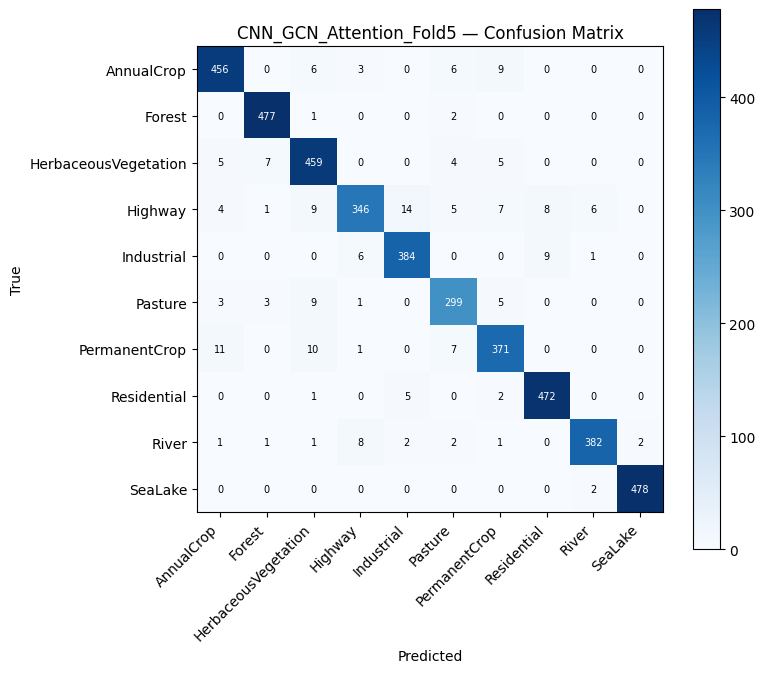

CNN_GCN_Attention HP2: mean_acc=0.9563 ± 0.0029, mean_f1=0.9542

CNN_GCN_Attention | Hyperparameter set 3/3 | {'lr': 7e-05, 'weight_decay': 5e-05, 'dropout': 0.25}
[CNN_GCN_Attention_F1_HP3] Epoch 1/8 - train_loss=1.3170 train_acc=0.6552 val_loss=0.6592 val_acc=0.8451
[CNN_GCN_Attention_F1_HP3] Epoch 2/8 - train_loss=0.6271 train_acc=0.8399 val_loss=0.3847 val_acc=0.8970
[CNN_GCN_Attention_F1_HP3] Epoch 3/8 - train_loss=0.4529 train_acc=0.8760 val_loss=0.2728 val_acc=0.9208
[CNN_GCN_Attention_F1_HP3] Epoch 4/8 - train_loss=0.3527 train_acc=0.9003 val_loss=0.2181 val_acc=0.9333
[CNN_GCN_Attention_F1_HP3] Epoch 5/8 - train_loss=0.3085 train_acc=0.9105 val_loss=0.1755 val_acc=0.9481
[CNN_GCN_Attention_F1_HP3] Epoch 6/8 - train_loss=0.2809 train_acc=0.9167 val_loss=0.1717 val_acc=0.9463
[CNN_GCN_Attention_F1_HP3] Epoch 7/8 - train_loss=0.2548 train_acc=0.9238 val_loss=0.1369 val_acc=0.9597
[CNN_GCN_Attention_F1_HP3] Epoch 8/8 - train_loss=0.2268 train_acc=0.9324 val_loss=0.1501 val_acc=0.9

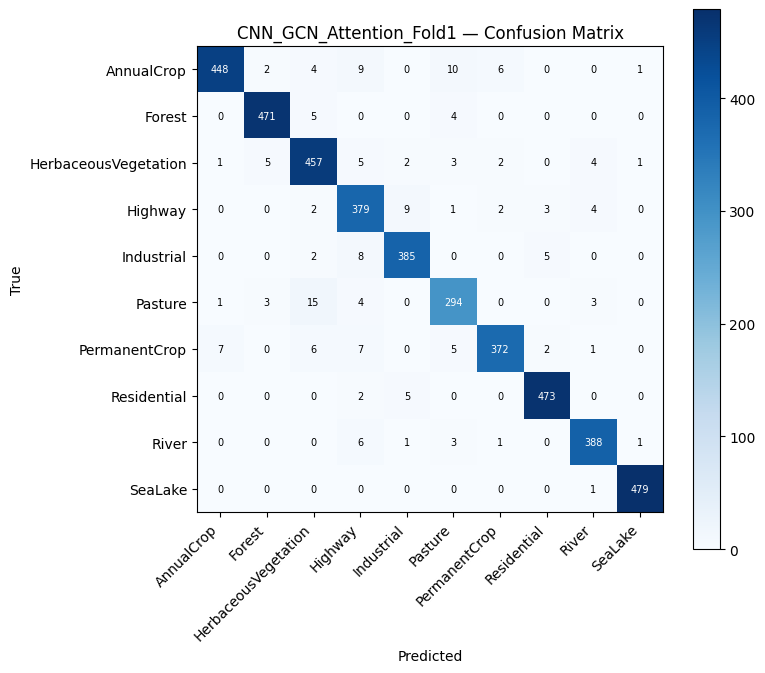

[CNN_GCN_Attention_F2_HP3] Epoch 1/8 - train_loss=1.3055 train_acc=0.6634 val_loss=0.6340 val_acc=0.8685
[CNN_GCN_Attention_F2_HP3] Epoch 2/8 - train_loss=0.6101 train_acc=0.8484 val_loss=0.3461 val_acc=0.9067
[CNN_GCN_Attention_F2_HP3] Epoch 3/8 - train_loss=0.4306 train_acc=0.8824 val_loss=0.2533 val_acc=0.9301
[CNN_GCN_Attention_F2_HP3] Epoch 4/8 - train_loss=0.3563 train_acc=0.8980 val_loss=0.2308 val_acc=0.9313
[CNN_GCN_Attention_F2_HP3] Epoch 5/8 - train_loss=0.3123 train_acc=0.9104 val_loss=0.1689 val_acc=0.9512
[CNN_GCN_Attention_F2_HP3] Epoch 6/8 - train_loss=0.2728 train_acc=0.9215 val_loss=0.1474 val_acc=0.9565
[CNN_GCN_Attention_F2_HP3] Epoch 7/8 - train_loss=0.2551 train_acc=0.9241 val_loss=0.1424 val_acc=0.9572
[CNN_GCN_Attention_F2_HP3] Epoch 8/8 - train_loss=0.2317 train_acc=0.9306 val_loss=0.1345 val_acc=0.9588

=== CNN_GCN_Attention_Fold2 — Test Set Results ===
Accuracy:  0.9588
Precision (macro): 0.9588
Recall (macro):    0.9556
F1 (macro):        0.9569

           

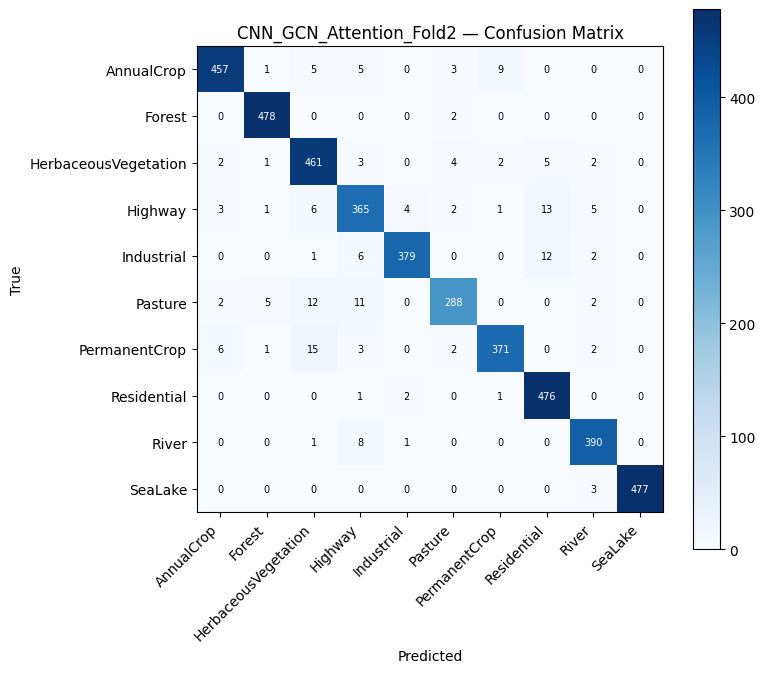

[CNN_GCN_Attention_F3_HP3] Epoch 1/8 - train_loss=1.3005 train_acc=0.6442 val_loss=0.6957 val_acc=0.8255
[CNN_GCN_Attention_F3_HP3] Epoch 2/8 - train_loss=0.6798 train_acc=0.8179 val_loss=0.4028 val_acc=0.8850
[CNN_GCN_Attention_F3_HP3] Epoch 3/8 - train_loss=0.4862 train_acc=0.8654 val_loss=0.3014 val_acc=0.9118
[CNN_GCN_Attention_F3_HP3] Epoch 4/8 - train_loss=0.3915 train_acc=0.8892 val_loss=0.2409 val_acc=0.9273
[CNN_GCN_Attention_F3_HP3] Epoch 5/8 - train_loss=0.3251 train_acc=0.9019 val_loss=0.2302 val_acc=0.9280
[CNN_GCN_Attention_F3_HP3] Epoch 6/8 - train_loss=0.2916 train_acc=0.9153 val_loss=0.1889 val_acc=0.9382
[CNN_GCN_Attention_F3_HP3] Epoch 7/8 - train_loss=0.2684 train_acc=0.9208 val_loss=0.1626 val_acc=0.9458
[CNN_GCN_Attention_F3_HP3] Epoch 8/8 - train_loss=0.2497 train_acc=0.9242 val_loss=0.1613 val_acc=0.9491

=== CNN_GCN_Attention_Fold3 — Test Set Results ===
Accuracy:  0.9491
Precision (macro): 0.9483
Recall (macro):    0.9469
F1 (macro):        0.9471

           

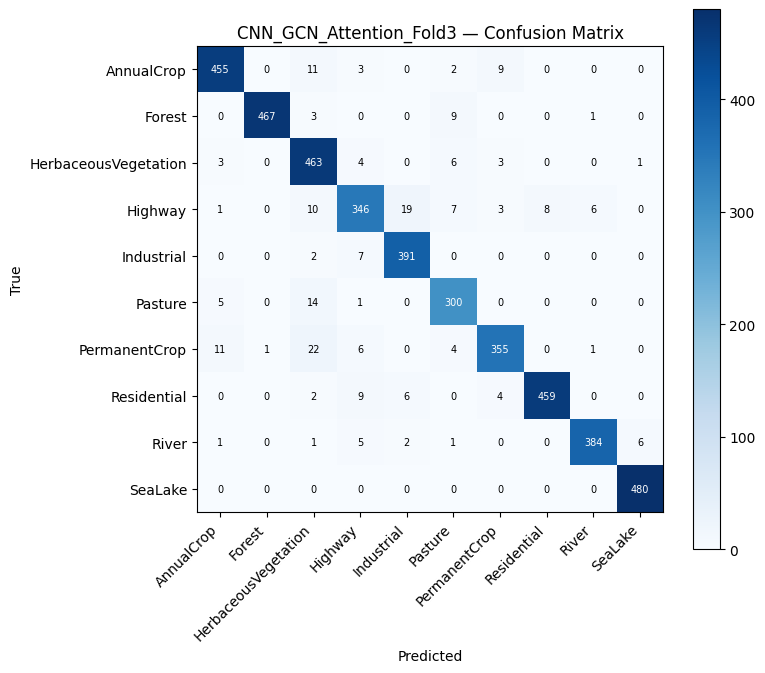

[CNN_GCN_Attention_F4_HP3] Epoch 1/8 - train_loss=1.3287 train_acc=0.6449 val_loss=0.6964 val_acc=0.8343
[CNN_GCN_Attention_F4_HP3] Epoch 2/8 - train_loss=0.6463 train_acc=0.8344 val_loss=0.3753 val_acc=0.9079
[CNN_GCN_Attention_F4_HP3] Epoch 3/8 - train_loss=0.4507 train_acc=0.8761 val_loss=0.2850 val_acc=0.9181
[CNN_GCN_Attention_F4_HP3] Epoch 4/8 - train_loss=0.3610 train_acc=0.8966 val_loss=0.2177 val_acc=0.9329
[CNN_GCN_Attention_F4_HP3] Epoch 5/8 - train_loss=0.3136 train_acc=0.9099 val_loss=0.1859 val_acc=0.9465
[CNN_GCN_Attention_F4_HP3] Epoch 6/8 - train_loss=0.2800 train_acc=0.9171 val_loss=0.1860 val_acc=0.9431
[CNN_GCN_Attention_F4_HP3] Epoch 7/8 - train_loss=0.2494 train_acc=0.9249 val_loss=0.1576 val_acc=0.9514
[CNN_GCN_Attention_F4_HP3] Epoch 8/8 - train_loss=0.2273 train_acc=0.9311 val_loss=0.1680 val_acc=0.9498

=== CNN_GCN_Attention_Fold4 — Test Set Results ===
Accuracy:  0.9514
Precision (macro): 0.9509
Recall (macro):    0.9470
F1 (macro):        0.9485

           

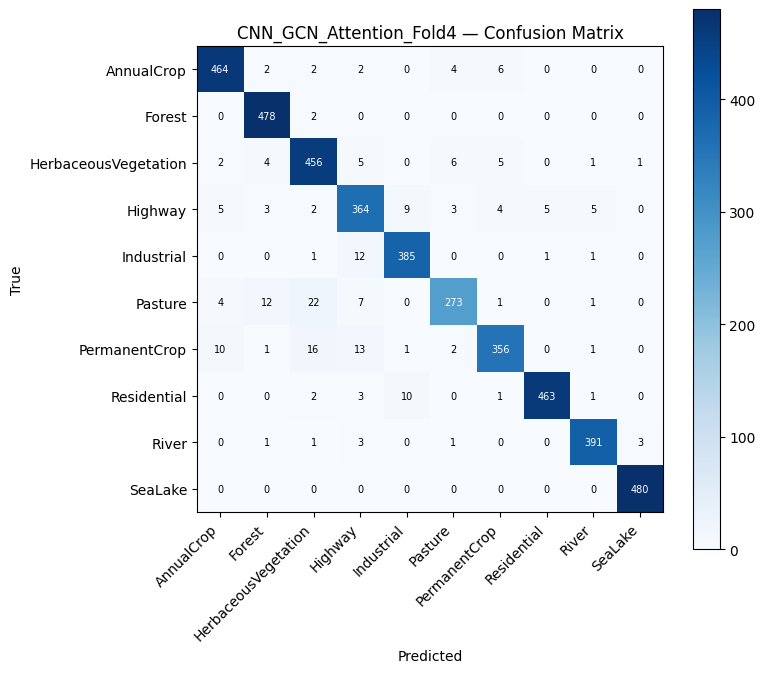

[CNN_GCN_Attention_F5_HP3] Epoch 1/8 - train_loss=1.3386 train_acc=0.6337 val_loss=0.6877 val_acc=0.8486
[CNN_GCN_Attention_F5_HP3] Epoch 2/8 - train_loss=0.6572 train_acc=0.8301 val_loss=0.3702 val_acc=0.8975
[CNN_GCN_Attention_F5_HP3] Epoch 3/8 - train_loss=0.4657 train_acc=0.8697 val_loss=0.3132 val_acc=0.9009
[CNN_GCN_Attention_F5_HP3] Epoch 4/8 - train_loss=0.3782 train_acc=0.8909 val_loss=0.2422 val_acc=0.9259
[CNN_GCN_Attention_F5_HP3] Epoch 5/8 - train_loss=0.3246 train_acc=0.9057 val_loss=0.2257 val_acc=0.9278
[CNN_GCN_Attention_F5_HP3] Epoch 6/8 - train_loss=0.2866 train_acc=0.9163 val_loss=0.2242 val_acc=0.9294
[CNN_GCN_Attention_F5_HP3] Epoch 7/8 - train_loss=0.2607 train_acc=0.9191 val_loss=0.1612 val_acc=0.9498
[CNN_GCN_Attention_F5_HP3] Epoch 8/8 - train_loss=0.2381 train_acc=0.9263 val_loss=0.1621 val_acc=0.9502

=== CNN_GCN_Attention_Fold5 — Test Set Results ===
Accuracy:  0.9498
Precision (macro): 0.9499
Recall (macro):    0.9470
F1 (macro):        0.9481

           

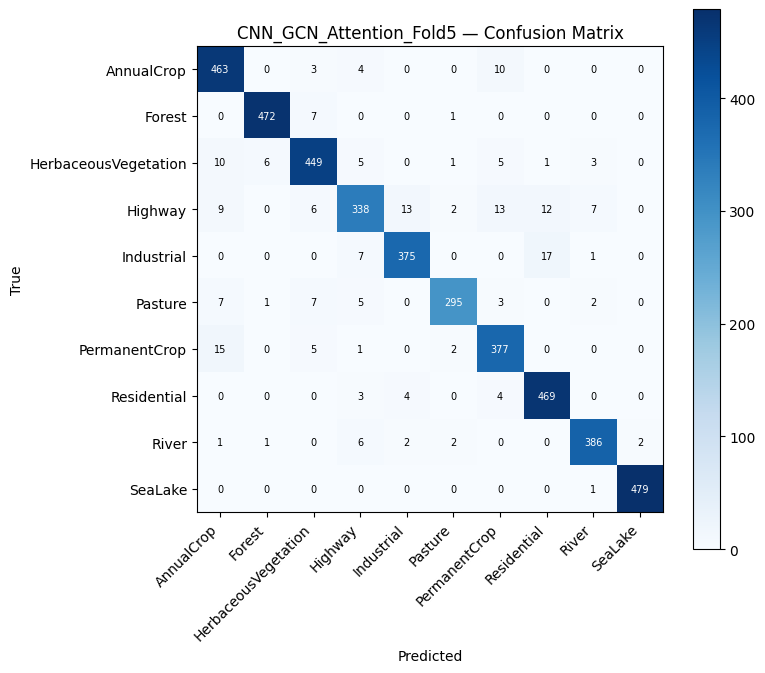

CNN_GCN_Attention HP3: mean_acc=0.9537 ± 0.0046, mean_f1=0.9517

================ BEST CV CONFIGURATIONS ================
ResNet18: {'model': 'ResNet18', 'hp_id': 2, 'lr': 0.0001, 'weight_decay': 0.0001, 'dropout': nan, 'mean_val_accuracy': 0.976574074074074, 'std_val_accuracy': 0.0017120242673241556, 'mean_val_f1': 0.9755967364863476}
CNN+GCN+Attention: {'model': 'CNN_GCN_Attention', 'hp_id': 2, 'lr': 0.0001, 'weight_decay': 0.0001, 'dropout': 0.35, 'mean_val_accuracy': 0.95625, 'std_val_accuracy': 0.003253117898739659, 'mean_val_f1': 0.9542396682868102}

================ FINAL RESNET18 TRAINING ================
[ResNet18_MS_Final] Epoch 1/25 - train_loss=0.3970 train_acc=0.8756 val_loss=0.1191 val_acc=0.9583
[ResNet18_MS_Final] Epoch 2/25 - train_loss=0.1511 train_acc=0.9518 val_loss=0.0838 val_acc=0.9687
[ResNet18_MS_Final] Epoch 3/25 - train_loss=0.1154 train_acc=0.9623 val_loss=0.0530 val_acc=0.9813
[ResNet18_MS_Final] Epoch 4/25 - train_loss=0.0987 train_acc=0.9675 val_loss=0.061

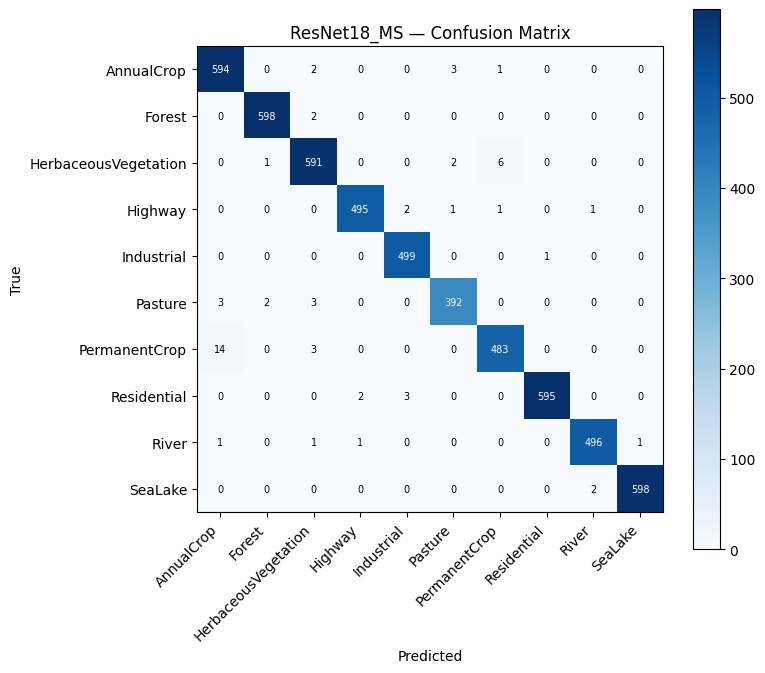


=== CNN_GCN_Attention — Test Set Results ===
Accuracy:  0.9835
Precision (macro): 0.9826
Recall (macro):    0.9829
F1 (macro):        0.9827

                      precision    recall  f1-score   support

          AnnualCrop       0.99      0.98      0.99       600
              Forest       0.99      0.99      0.99       600
HerbaceousVegetation       0.98      0.98      0.98       600
             Highway       0.98      0.96      0.97       500
          Industrial       0.98      0.98      0.98       500
             Pasture       0.96      0.98      0.97       400
       PermanentCrop       0.98      0.98      0.98       500
         Residential       0.98      0.99      0.99       600
               River       0.99      0.99      0.99       500
             SeaLake       1.00      1.00      1.00       600

            accuracy                           0.98      5400
           macro avg       0.98      0.98      0.98      5400
        weighted avg       0.98      0.98      0.

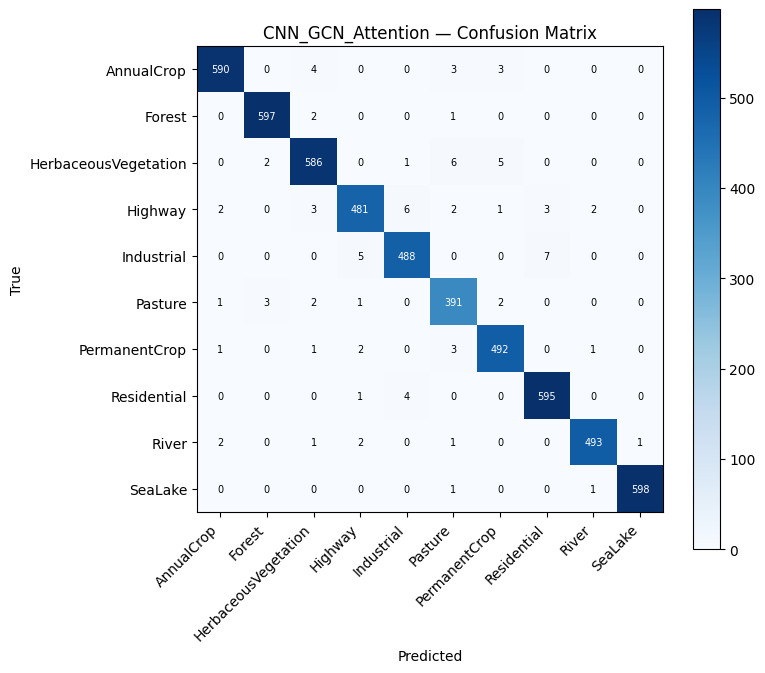

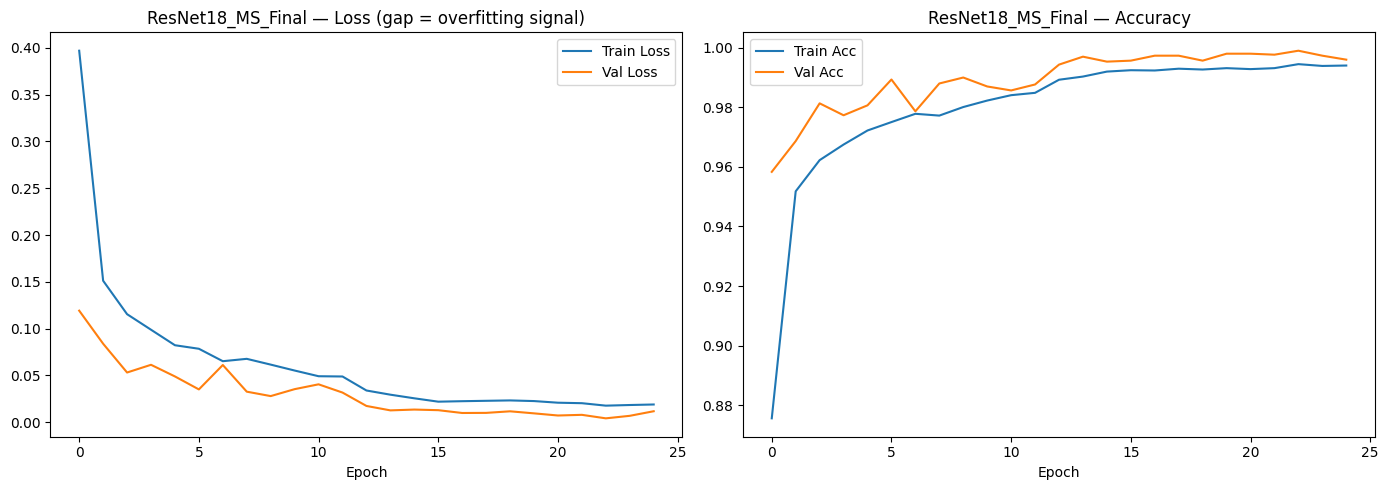

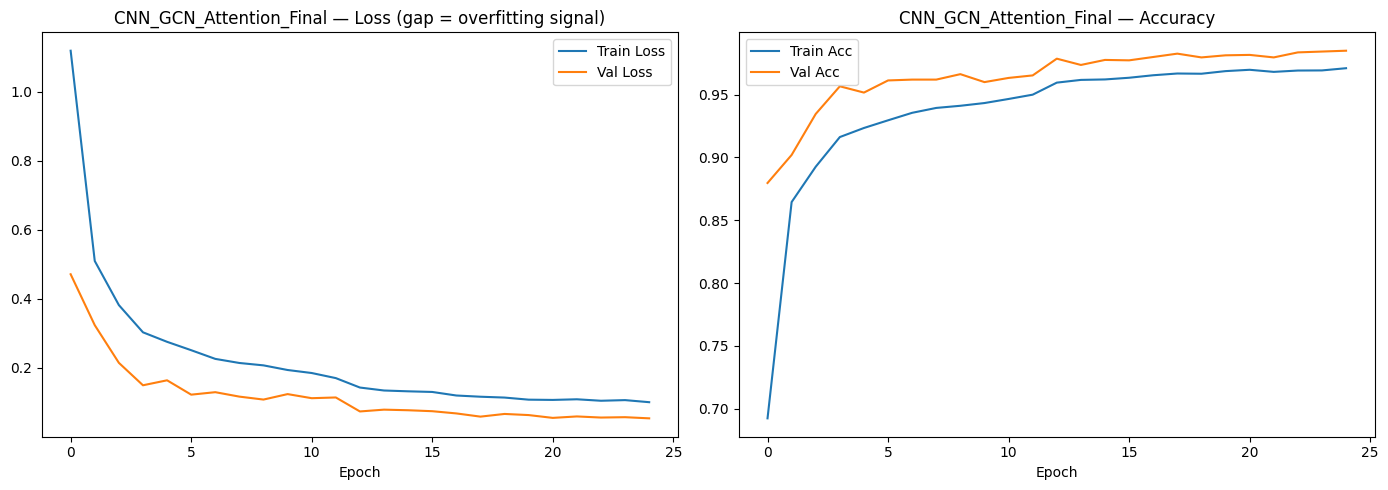

In [35]:
# ----------------------------------------------------------------
# 13.5. STRATIFIED 5-FOLD CV + HYPERPARAMETER TUNING + FINE-TUNING
# ----------------------------------------------------------------

def set_seed(seed=SEED):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def compute_fold_stats(frame, max_samples=300):
    """Compute normalization from the training fold only."""
    sample = frame.sample(min(max_samples, len(frame)), random_state=SEED)
    sums = None
    sums_sq = None
    count = 0

    for path in sample["filepath"]:
        arr = get_band_array(path).astype(np.float32)  # H,W,C
        flat = arr.reshape(-1, arr.shape[-1])
        s = flat.sum(axis=0)
        ss = (flat ** 2).sum(axis=0)

        if sums is None:
            sums = s
            sums_sq = ss
        else:
            sums += s
            sums_sq += ss
        count += flat.shape[0]

    mean = sums / count
    var = np.maximum(sums_sq / count - mean ** 2, 1e-8)
    std = np.sqrt(var)
    return mean.astype(np.float32), std.astype(np.float32)


def make_model(model_type, lr, dropout=0.35):
    if model_type == "ResNet18":
        model = build_resnet18_ms(
            num_classes=NUM_CLASSES,
            in_channels=len(BAND_NAMES),
            pretrained=True
        )
    else:
        model = CNN_GCN_Attention(
            in_channels=len(BAND_NAMES),
            num_classes=NUM_CLASSES,
            gcn_dim=128,
            num_heads=4,
            dropout=dropout
        )
    return model


def train_one_fold(model, model_name, train_loader, val_loader,
                   epochs, lr, weight_decay, patience):
    return train_model(
        model, model_name, train_loader, val_loader,
        epochs=epochs, lr=lr,
        weight_decay=weight_decay, patience=patience
    )


resnet_grid = [
    {"lr": 3e-4, "weight_decay": 1e-4},
    {"lr": 1e-4, "weight_decay": 1e-4},
]

gcn_grid = [
    {"lr": 3e-4, "weight_decay": 1e-4, "dropout": 0.25},
    {"lr": 1e-4, "weight_decay": 1e-4, "dropout": 0.35},
    {"lr": 7e-5, "weight_decay": 5e-5, "dropout": 0.25},
]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


def run_cv(model_type, grid):
    all_rows = []
    labels = dev_df["label"].values

    for hp_id, hp in enumerate(grid, start=1):
        fold_accs = []
        fold_f1s = []

        print("\n" + "=" * 80)
        print(f"{model_type} | Hyperparameter set {hp_id}/{len(grid)} | {hp}")
        print("=" * 80)

        for fold, (tr_idx, va_idx) in enumerate(skf.split(dev_df, labels), start=1):
            set_seed(SEED + fold + hp_id)

            tr_part = dev_df.iloc[tr_idx].reset_index(drop=True)
            va_part = dev_df.iloc[va_idx].reset_index(drop=True)

            # Fold-specific normalization: validation images never influence stats.
            fold_mean, fold_std = compute_fold_stats(tr_part)

            train_loader_fold, val_loader_fold = make_loaders(
                tr_part, va_part,
                fold_mean, fold_std,
                strong_train=(model_type == "CNN_GCN_Attention"),
                batch_size=CV_BATCH_SIZE
            )

            model = make_model(
                "ResNet18" if model_type == "ResNet18" else "CNN_GCN_Attention",
                lr=hp["lr"],
                dropout=hp.get("dropout", 0.35)
            )

            model, hist = train_one_fold(
                model,
                f"{model_type}_F{fold}_HP{hp_id}",
                train_loader_fold,
                val_loader_fold,
                epochs=CV_EPOCHS,
                lr=hp["lr"],
                weight_decay=hp["weight_decay"],
                patience=3
            )

            fold_result = evaluate_model(
                model, val_loader_fold,
                f"{model_type}_Fold{fold}"
            )

            fold_accs.append(float(fold_result["accuracy"]))
            fold_f1s.append(float(fold_result["f1"]))

            all_rows.append({
                "model": model_type,
                "hp_id": hp_id,
                "fold": fold,
                "lr": hp["lr"],
                "weight_decay": hp["weight_decay"],
                "dropout": hp.get("dropout", np.nan),
                "val_accuracy": fold_result["accuracy"],
                "val_f1": fold_result["f1"]
            })

            del model, train_loader_fold, val_loader_fold
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        print(
            f"{model_type} HP{hp_id}: "
            f"mean_acc={np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}, "
            f"mean_f1={np.mean(fold_f1s):.4f}"
        )

    cv_df = pd.DataFrame(all_rows)

    summary = (
        cv_df.groupby(["model", "hp_id", "lr", "weight_decay", "dropout"], dropna=False)
        .agg(
            mean_val_accuracy=("val_accuracy", "mean"),
            std_val_accuracy=("val_accuracy", "std"),
            mean_val_f1=("val_f1", "mean")
        )
        .reset_index()
        .sort_values(["mean_val_accuracy", "mean_val_f1"], ascending=False)
    )

    best = summary.iloc[0].to_dict()
    return cv_df, summary, best


resnet_cv_df, resnet_cv_summary, best_resnet_hp = run_cv(
    "ResNet18", resnet_grid
)

gcn_cv_df, gcn_cv_summary, best_gcn_hp = run_cv(
    "CNN_GCN_Attention", gcn_grid
)

cv_summary_all = pd.concat(
    [resnet_cv_summary, gcn_cv_summary],
    ignore_index=True
)
cv_summary_all.to_csv("KFold_Hyperparameter_Summary.csv", index=False)

print("\n================ BEST CV CONFIGURATIONS ================")
print("ResNet18:", best_resnet_hp)
print("CNN+GCN+Attention:", best_gcn_hp)


# ------------------------------------------------------------
# FINAL TRAINING + LOW-LR FINE-TUNING ON ALL 80% DEVELOPMENT DATA
# ------------------------------------------------------------
def fine_tune_model(model, model_name, train_loader, val_loader=None,
                    base_lr=1e-4, epochs=FINETUNE_EPOCHS):
    """
    Fine-tuning stage:
    - first 2 epochs: classifier / higher-level layers are optimized;
    - remaining epochs: all layers are unfrozen at low LR.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    # Freeze feature extractor for the first stage.
    frozen_names = []
    if model_name == "ResNet18_MS":
        for name, p in model.named_parameters():
            if name.startswith("fc"):
                p.requires_grad = True
            else:
                p.requires_grad = False
                frozen_names.append(name)
    else:
        # For the proposed model, freeze CNN first and tune GCN/attention/classifier.
        for name, p in model.named_parameters():
            if name.startswith("cnn."):
                p.requires_grad = False
                frozen_names.append(name)
            else:
                p.requires_grad = True

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=base_lr,
        weight_decay=5e-5
    )

    warm_epochs = min(2, epochs)
    for ep in range(warm_epochs):
        model.train()
        total_loss = 0.0
        total = 0
        correct = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()

            total_loss += loss.item() * x.size(0)
            total += x.size(0)
            correct += (out.argmax(1) == y).sum().item()

        print(
            f"[{model_name}][head fine-tune] "
            f"{ep+1}/{warm_epochs} "
            f"loss={total_loss/total:.4f} acc={correct/total:.4f}"
        )

    # Unfreeze everything and fine-tune end-to-end with a lower LR.
    for p in model.parameters():
        p.requires_grad = True

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=base_lr * 0.3,
        weight_decay=5e-5
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=max(1, epochs - warm_epochs)
    )

    for ep in range(warm_epochs, epochs):
        model.train()
        total_loss = 0.0
        total = 0
        correct = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()

            total_loss += loss.item() * x.size(0)
            total += x.size(0)
            correct += (out.argmax(1) == y).sum().item()

        scheduler.step()

        print(
            f"[{model_name}][end-to-end fine-tune] "
            f"{ep+1}/{epochs} "
            f"loss={total_loss/total:.4f} acc={correct/total:.4f} "
            f"lr={opt.param_groups[0]['lr']:.2e}"
        )

    return model


# Rebuild final models using the best CV hyperparameters.
set_seed(SEED)

resnet_model = make_model(
    "ResNet18",
    lr=float(best_resnet_hp["lr"])
)

cnn_gcn_att_model = make_model(
    "CNN_GCN_Attention",
    lr=float(best_gcn_hp["lr"]),
    dropout=float(best_gcn_hp["dropout"])
)

# Normal full-development training before fine-tuning.
# For ResNet, pretrained ImageNet weights are fine-tuned on all development data.
print("\n================ FINAL RESNET18 TRAINING ================")
resnet_model, resnet_history = train_model(
    resnet_model,
    "ResNet18_MS_Final",
    full_dev_resnet_loader,
    None if False else DataLoader(
        EuroSATMSDataset(dev_df.sample(min(3000, len(dev_df)), random_state=SEED),
                         BAND_MEAN, BAND_STD, train=False),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    ),
    epochs=FINAL_EPOCHS,
    lr=float(best_resnet_hp["lr"]),
    weight_decay=float(best_resnet_hp["weight_decay"]),
    patience=5
)

print("\n================ RESNET18 LOW-LR FINE-TUNING ================")
resnet_model = fine_tune_model(
    resnet_model,
    "ResNet18_MS",
    full_dev_resnet_loader,
    base_lr=float(best_resnet_hp["lr"]) * 0.5,
    epochs=FINETUNE_EPOCHS
)

print("\n================ FINAL CNN+GCN+ATT TRAINING ================")
cnn_gcn_att_model, cnn_gcn_att_history = train_model(
    cnn_gcn_att_model,
    "CNN_GCN_Attention_Final",
    full_dev_gcn_loader,
    DataLoader(
        EuroSATMSDataset(dev_df.sample(min(3000, len(dev_df)), random_state=SEED),
                         BAND_MEAN, BAND_STD, train=False),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    ),
    epochs=FINAL_EPOCHS,
    lr=float(best_gcn_hp["lr"]),
    weight_decay=float(best_gcn_hp["weight_decay"]),
    patience=5
)

print("\n================ CNN+GCN+ATT LOW-LR FINE-TUNING ================")
cnn_gcn_att_model = fine_tune_model(
    cnn_gcn_att_model,
    "CNN_GCN_Attention",
    full_dev_gcn_loader,
    base_lr=float(best_gcn_hp["lr"]) * 0.5,
    epochs=FINETUNE_EPOCHS
)

# FINAL TEST — used only now.
resnet_results = evaluate_model(resnet_model, test_loader, "ResNet18_MS")
cnn_gcn_att_results = evaluate_model(
    cnn_gcn_att_model, test_loader, "CNN_GCN_Attention"
)

plot_overfitting_curves(resnet_history, "ResNet18_MS_Final")
plot_overfitting_curves(cnn_gcn_att_history, "CNN_GCN_Attention_Final")


In [36]:
# ----------------------------------------------------------------
# 14. SAVE BEST MODEL CHECKPOINTS
# ----------------------------------------------------------------

torch.save({
    "model_state_dict": resnet_model.state_dict(),
    "class_names": class_names,
    "band_names": BAND_NAMES,
    "band_mean": BAND_MEAN,
    "band_std": BAND_STD,
}, "best_resnet18_ms.pth")

torch.save({
    "model_state_dict": cnn_gcn_att_model.state_dict(),
    "class_names": class_names,
    "band_names": BAND_NAMES,
    "band_mean": BAND_MEAN,
    "band_std": BAND_STD,
}, "best_cnn_gcn_attention.pth")

print("Saved:")
print(" - best_resnet18_ms.pth")
print(" - best_cnn_gcn_attention.pth")


Saved:
 - best_resnet18_ms.pth
 - best_cnn_gcn_attention.pth



================ 5-FOLD CV SUMMARY ================
            model  hp_id      lr  weight_decay  dropout  mean_val_accuracy  std_val_accuracy  mean_val_f1
         ResNet18      2 0.00010       0.00010      NaN           0.976574          0.001712     0.975597
         ResNet18      1 0.00030       0.00010      NaN           0.972778          0.004631     0.971674
CNN_GCN_Attention      2 0.00010       0.00010     0.35           0.956250          0.003253     0.954240
CNN_GCN_Attention      3 0.00007       0.00005     0.25           0.953750          0.005109     0.951697
CNN_GCN_Attention      1 0.00030       0.00010     0.25           0.951806          0.004651     0.949985

================ FINAL TEST COMPARISON ================
            model  accuracy  precision   recall       f1  parameters
      ResNet18_MS  0.989074   0.989065 0.988600 0.988811    11213002
CNN_GCN_Attention  0.983519   0.982574 0.982883 0.982708      325867

BEST MODEL BY TEST ACCURACY: ResNet18_MS
BEST 

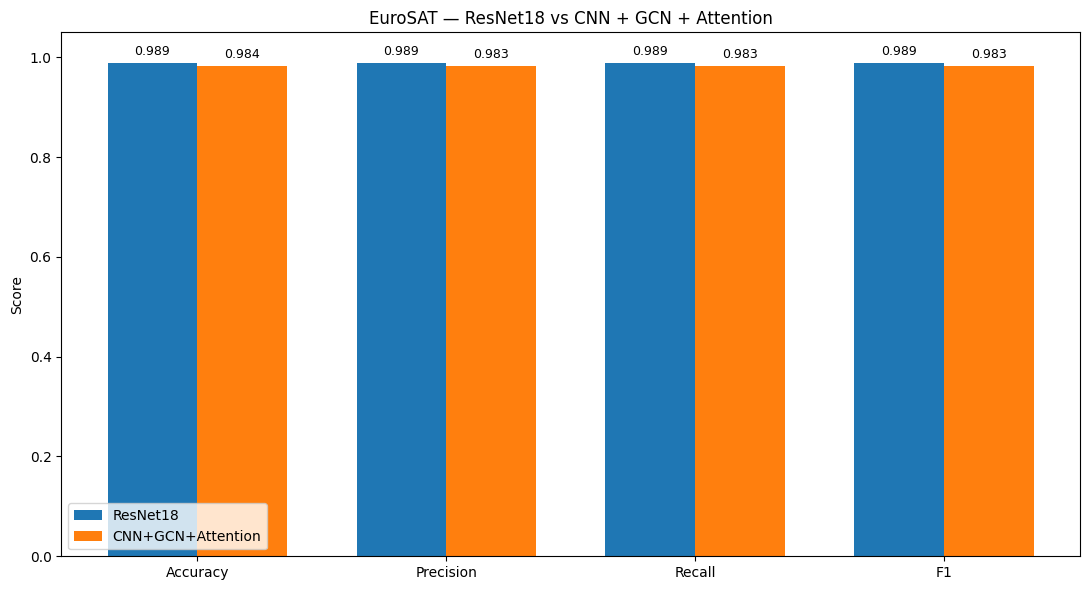

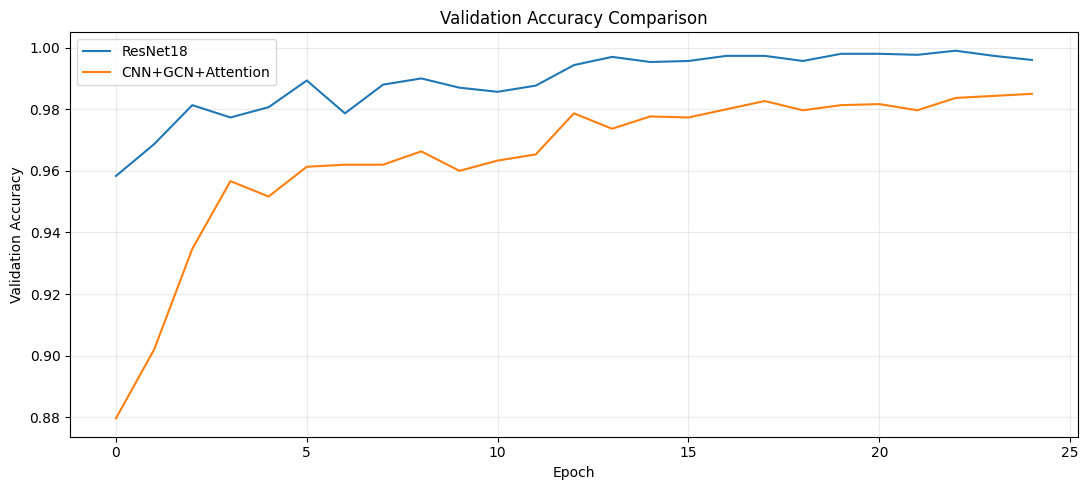

In [37]:
# ----------------------------------------------------------------
# 15. FINAL MODEL COMPARISON — 5-FOLD + FINE-TUNED MODELS
# ----------------------------------------------------------------

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Rebuild the comparison from the actual test-set results.
results = [resnet_results, cnn_gcn_att_results]
comparison_df = pd.DataFrame(results).copy()
comparison_df["parameters"] = [count_params(resnet_model), count_params(cnn_gcn_att_model)]

print("\n================ 5-FOLD CV SUMMARY ================")
print(cv_summary_all.to_string(index=False))
print("\n================ FINAL TEST COMPARISON ================")
print(comparison_df.to_string(index=False))

comparison_df.to_csv("ResNet18_vs_CNN_GCN_Attention.csv", index=False)

# Best model by test accuracy
best_idx = comparison_df["accuracy"].idxmax()
best_name = comparison_df.loc[best_idx, "model"]
best_acc = comparison_df.loc[best_idx, "accuracy"]
print(f"\nBEST MODEL BY TEST ACCURACY: {best_name}")
print(f"BEST TEST ACCURACY: {best_acc:.4%}")

# Improvement of CNN+GCN+Attention over ResNet18
resnet_acc = float(comparison_df.loc[comparison_df["model"] == "ResNet18_MS", "accuracy"].iloc[0])
gcn_acc = float(comparison_df.loc[comparison_df["model"] == "CNN_GCN_Attention", "accuracy"].iloc[0])
print(f"CNN+GCN+Attention - ResNet18 accuracy difference: {(gcn_acc - resnet_acc):+.4%}")

# Metrics bar chart
metrics = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metrics))
width = 0.36

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, comparison_df.iloc[0][metrics].astype(float), width, label="ResNet18")
plt.bar(x + width/2, comparison_df.iloc[1][metrics].astype(float), width, label="CNN+GCN+Attention")
plt.xticks(x, ["Accuracy", "Precision", "Recall", "F1"])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("EuroSAT — ResNet18 vs CNN + GCN + Attention")
plt.legend()
for i, v in enumerate(comparison_df.iloc[0][metrics].astype(float)):
    plt.text(i - width/2, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(comparison_df.iloc[1][metrics].astype(float)):
    plt.text(i + width/2, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("ResNet18_vs_CNN_GCN_Attention_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

# Validation accuracy curves
plt.figure(figsize=(11, 5))
plt.plot(resnet_history["val_acc"], label="ResNet18")
plt.plot(cnn_gcn_att_history["val_acc"], label="CNN+GCN+Attention")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("validation_accuracy_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


In [38]:
# ----------------------------------------------------------------
# 16. OPTIONAL — SAVE A SIMPLE SUMMARY FOR THE REPORT
# ----------------------------------------------------------------
summary = comparison_df[["model", "accuracy", "precision", "recall", "f1", "parameters"]].copy()
summary["accuracy_percent"] = summary["accuracy"] * 100
summary["f1_percent"] = summary["f1"] * 100
summary.to_csv("final_model_summary.csv", index=False)

print("Final files generated:")
for f in [
    "best_resnet18_ms.pth",
    "best_cnn_gcn_attention.pth",
    "ResNet18_vs_CNN_GCN_Attention.csv",
    "final_model_summary.csv",
    "ResNet18_vs_CNN_GCN_Attention_metrics.png",
    "validation_accuracy_comparison.png",
]:
    print(" -", f)


Final files generated:
 - best_resnet18_ms.pth
 - best_cnn_gcn_attention.pth
 - ResNet18_vs_CNN_GCN_Attention.csv
 - final_model_summary.csv
 - ResNet18_vs_CNN_GCN_Attention_metrics.png
 - validation_accuracy_comparison.png


In [40]:
# ----------------------------------------------------------------
# 18. TASK 2 FIX — CLASS-IMBALANCE-AWARE TRAINING
# ----------------------------------------------------------------
_class_counts = dev_df["label"].value_counts().reindex(sorted(class_names)).values.astype(np.float32)
_class_weights = (_class_counts.sum() / (len(_class_counts) * _class_counts))
CLASS_WEIGHTS = torch.tensor(_class_weights, dtype=torch.float32)

print("Class weights (imbalance handling):")
for cls, w in zip(sorted(class_names), CLASS_WEIGHTS.tolist()):
    print(f"  {cls:20s} weight={w:.3f}")


def train_model_full(model, model_name, train_loader, val_loader, epochs=EPOCHS,
                      lr=LR, weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                      class_weights=None, label_smoothing=0.0):
    """Same loop as train_model, plus class weights, label smoothing, and
    wall-clock training time (needed for the Task 2 full metric set)."""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    weight_tensor = class_weights.to(DEVICE) if class_weights is not None else None
    criterion = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=label_smoothing)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                            factor=0.5, patience=2)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                loss = criterion(out, y)
                val_running_loss += loss.item() * x.size(0)
                val_correct += (out.argmax(1) == y).sum().item()
                val_total += x.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} - "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{model_name}] Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    train_time = time.time() - t0
    return model, history, train_time


Class weights (imbalance handling):
  AnnualCrop           weight=0.900
  Forest               weight=0.900
  HerbaceousVegetation weight=0.900
  Highway              weight=1.080
  Industrial           weight=1.080
  Pasture              weight=1.350
  PermanentCrop        weight=1.080
  Residential          weight=0.900
  River                weight=1.080
  SeaLake              weight=0.900


In [41]:
# ----------------------------------------------------------------
# 19. TASK 2 FIX — FULL METRIC SET: TRAINING TIME + PARAM COUNT + MODEL SIZE
# ----------------------------------------------------------------
def get_model_size_mb(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return buffer.getbuffer().nbytes / (1024 ** 2)


def evaluate_model_full(model, loader, model_name, train_time=None):
    results = evaluate_model(model, loader, model_name)
    results["parameters"] = count_params(model)
    results["model_size_mb"] = get_model_size_mb(model)
    results["train_time_sec"] = train_time if train_time is not None else np.nan
    return results

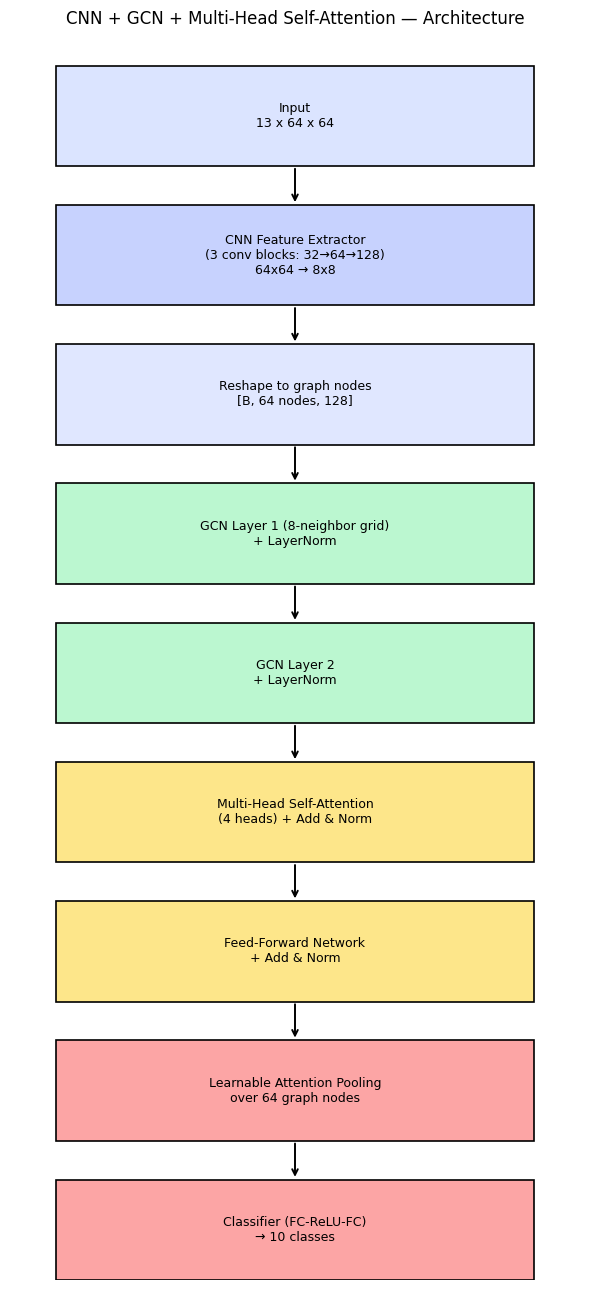

In [44]:
# ----------------------------------------------------------------
# 22. TASK 2 FIX — ARCHITECTURE DIAGRAM
# ----------------------------------------------------------------
blocks = [
    ("Input\n13 x 64 x 64", "#dbe4ff"),
    ("CNN Feature Extractor\n(3 conv blocks: 32\u219264\u2192128)\n64x64 \u2192 8x8", "#c7d2fe"),
    ("Reshape to graph nodes\n[B, 64 nodes, 128]", "#e0e7ff"),
    ("GCN Layer 1 (8-neighbor grid)\n+ LayerNorm", "#bbf7d0"),
    ("GCN Layer 2\n+ LayerNorm", "#bbf7d0"),
    ("Multi-Head Self-Attention\n(4 heads) + Add & Norm", "#fde68a"),
    ("Feed-Forward Network\n+ Add & Norm", "#fde68a"),
    ("Learnable Attention Pooling\nover 64 graph nodes", "#fca5a5"),
    ("Classifier (FC-ReLU-FC)\n\u2192 10 classes", "#fca5a5"),
]

box_h, gap = 0.9, 0.35
n = len(blocks)
total_h = n * box_h + (n - 1) * gap

fig, ax = plt.subplots(figsize=(6, 13))
ax.axis("off")
for i, (text, color) in enumerate(blocks):
    y_top = total_h - i * (box_h + gap)
    y_bottom = y_top - box_h
    ax.add_patch(plt.Rectangle((0.08, y_bottom), 0.84, box_h,
                                facecolor=color, edgecolor="black", linewidth=1.2))
    ax.text(0.5, y_bottom + box_h / 2, text, ha="center", va="center", fontsize=9)
    if i > 0:
        prev_bottom = total_h - (i - 1) * (box_h + gap) - box_h
        ax.annotate("", xy=(0.5, y_top), xytext=(0.5, prev_bottom),
                    arrowprops=dict(arrowstyle="->", lw=1.4))

ax.set_xlim(0, 1)
ax.set_ylim(0, total_h + 0.3)
ax.set_title("CNN + GCN + Multi-Head Self-Attention \u2014 Architecture", fontsize=12)
plt.tight_layout()
plt.savefig("cnn_gcn_attention_architecture.png", dpi=200, bbox_inches="tight")
plt.show()